# 1\.2\.2 Standardize spatial representation

This notebook standardizes the spatial representation used across the Traffic, Bus, and Subway mobility datasets by aligning observations to the project's canonical Taxi Zone geography\. Traffic roadway locations, Bus route segments, and Subway station complexes all arrive with different native spatial structures, which makes direct comparison awkward until they share a common zone\-based frame\. By assigning Taxi Zone IDs and related geographic attributes where appropriate, this notebook establishes the spatial foundation needed for harmonization, multimodal integration, and later zone\-level analysis\.

In [109]:
!pip install folium matplotlib mapclassify


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [110]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import branca.colormap as bcm

import gc
from tqdm.auto import tqdm

import duckdb

from shapely.geometry import Point
from shapely import wkt
from shapely.geometry import LineString

from project_branding import BRAND_COLORS


## 1\.2\.2\.1 Load staged files

In [111]:
# ---------------------------------------------------------------------
# Load temporal-standardized traffic data and taxi zone reference layer
# ---------------------------------------------------------------------

PIPELINE_DATA_DIR = Path("pipeline_data")

TRAFFIC_COUNTS_PATH = PIPELINE_DATA_DIR / "1.2.1.traffic_counts_temporal.parquet"
TAXI_ZONES_PATH = PIPELINE_DATA_DIR / "1.1.6.nyc_taxi_zones.parquet"

REGENERATE_SUBWAY_SPATIAL_FILES = False

traffic_counts = pd.read_parquet(TRAFFIC_COUNTS_PATH)
taxi_zones = gpd.read_parquet(TAXI_ZONES_PATH)

In [112]:
print("\nTaxi zones CRS:", taxi_zones.crs)


Taxi zones CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "sc

Findings\. The Taxi Zone polygons loaded in the expected WGS84 latitude/longitude coordinate system \(\`EPSG:4326\`\)\. That is the right starting point for the zone reference layer and makes the later CRS alignment steps explicit rather than implicit\.

## 1\.2\.2\.2 Add taxi zone id into traffic dataset

Spatially map roadway traffic observations into NYC Taxi Zones by joining roadway geometries against taxi zone polygons\. The resulting taxi zone identifiers will allow roadway traffic patterns to be aggregated, compared, and integrated alongside other NYC mobility datasets at a shared geographic level\.

In [113]:
traffic_counts.sample(5)

,segment_id,borough,street_name,from_street,to_street,direction,timestamp,traffic_volume,geometry_wkt,observation_count,...,day_of_week,hour,temporal_bucket,daypart,daypart_order,temporal_bucket_order,observation_sequence_id,pre_post_cp,temporal_grain_type,date_assignment_method
193960,147982,Brooklyn,ADAMS STREET,Johnson Street,Connector,NB,2023-10-16 11:00:00,200,POINT (987363.6729658039 192374.79121034782),1,...,Monday,11,weekday_midday,midday,3,3,1443,pre_cp,native_timestamp,derived_from_native_timestamp
27961,28962,Brooklyn,FLATBUSH AVENUE,Atlantic Avenue,Eastern Parkway Line,SB,2024-06-06 03:45:00,46,POINT (990590.8197336476 188336.94708352597),1,...,Thursday,3,weekday_overnight,overnight,1,1,2611,pre_cp,native_timestamp,derived_from_native_timestamp
242024,223885,Manhattan,HENRY HUDSON PARKWAY,Henry Hudson Py Nb En W 96 St,Dead end,NB,2024-05-05 11:30:00,676,POINT (991017.732192312 229786.22470530684),1,...,Sunday,11,weekend_midday,midday,3,3,2453,pre_cp,native_timestamp,derived_from_native_timestamp
255646,9000515,Queens,160 STREET,Dead End,Dead end,SB,2024-01-19 06:45:00,18,POINT (1041074.973834683 193690.47360957888),1,...,Friday,6,weekday_am_peak,am_peak,2,2,1917,pre_cp,native_timestamp,derived_from_native_timestamp
258724,9003591,Brooklyn,MYRTLE AVENUE,Throop Avenue,Tompkins Houses Pedestrian Path,WB,2023-05-01 10:15:00,53,POINT (999725.6730184525 192836.2813155484),1,...,Monday,10,weekday_midday,midday,3,3,603,pre_cp,native_timestamp,derived_from_native_timestamp


In [114]:
# ---------------------------------------------------------------------
# Parse roadway geometry from WKT into shapely objects
# ---------------------------------------------------------------------
# The staged traffic file stores roadway points as WKT text. Convert them to
# geometry objects before creating a GeoDataFrame and running spatial joins.

traffic_counts["geometry"] = traffic_counts["geometry_wkt"].apply(wkt.loads)

In [115]:
# ---------------------------------------------------------------------
# Convert traffic points to a GeoDataFrame in the source projected CRS
# ---------------------------------------------------------------------
# Traffic roadway coordinates arrive in NYC State Plane feet (`EPSG:2263`).
# Keep that CRS explicit here so the later reprojection and spatial join are auditable.

traffic_counts = gpd.GeoDataFrame(
    traffic_counts,
    geometry="geometry",
    crs="EPSG:2263"
)

In [116]:
# ---------------------------------------------------------------------
# Reproject roadway points to match the Taxi Zone CRS
# ---------------------------------------------------------------------
# The spatial join should happen with both layers in the same CRS. Taxi Zones
# are stored in `EPSG:4326`, so reproject the roadway points before joining.

traffic_counts = traffic_counts.to_crs(taxi_zones.crs)

In [117]:
# ---------------------------------------------------------------------
# Spatially join roadway points into Taxi Zones
# ---------------------------------------------------------------------
# Each roadway point inherits the Taxi Zone polygon that contains it. This is
# the step that puts Traffic on the same zone-based geographic frame as the
# other mobility datasets.

traffic_with_zones = gpd.sjoin(
    traffic_counts,
    taxi_zones[
        ["location_id", "zone", "borough", "geometry"]
    ],
    how="left",
    predicate="within"
)

In [118]:
traffic_with_zones.head()

,segment_id,borough_left,street_name,from_street,to_street,direction,timestamp,traffic_volume,geometry_wkt,observation_count,...,temporal_bucket_order,observation_sequence_id,pre_post_cp,temporal_grain_type,date_assignment_method,geometry,index_right,location_id,zone,borough_right
0,5164,Staten Island,GOETHALS ROAD NORTH,Staten Island Railway Line,Western Avenue,WB,2023-09-06 00:00:00,16,POINT (932655.1292010084 168977.97581364735),1,...,1,1241,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-74.18588 40.63033),155.0,156.0,Mariners Harbor,Staten Island
1,5164,Staten Island,GOETHALS ROAD NORTH,Staten Island Railway Line,Western Avenue,WB,2023-09-06 00:15:00,19,POINT (932655.1292010084 168977.97581364735),1,...,1,1241,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-74.18588 40.63033),155.0,156.0,Mariners Harbor,Staten Island
2,5164,Staten Island,GOETHALS ROAD NORTH,Staten Island Railway Line,Western Avenue,WB,2023-09-06 00:30:00,10,POINT (932655.1292010084 168977.97581364735),1,...,1,1241,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-74.18588 40.63033),155.0,156.0,Mariners Harbor,Staten Island
3,5164,Staten Island,GOETHALS ROAD NORTH,Staten Island Railway Line,Western Avenue,WB,2023-09-06 00:45:00,12,POINT (932655.1292010084 168977.97581364735),1,...,1,1241,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-74.18588 40.63033),155.0,156.0,Mariners Harbor,Staten Island
4,5164,Staten Island,GOETHALS ROAD NORTH,Staten Island Railway Line,Western Avenue,WB,2023-09-06 01:00:00,16,POINT (932655.1292010084 168977.97581364735),1,...,1,1241,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-74.18588 40.63033),155.0,156.0,Mariners Harbor,Staten Island


## 1\.2\.2\.3 Validate spatial join coverage and geographic consistency

This QA section checks whether roadway traffic points mapped into valid Taxi Zones the way we expect\. The main questions are coverage, unmapped edge cases, and whether the resulting borough and zone assignments look geographically plausible before the output moves downstream\.

In [119]:
# --------------------------------
# Step 1: Basic sanity QA checks
# --------------------------------

print("Shape:", traffic_with_zones.shape)
print("Nulls by location:", traffic_with_zones[['location_id', 'zone']].isna().sum())
print("Mean nulls by location:", traffic_with_zones['location_id'].isna().mean())

Shape: (270011, 28)
Nulls by location: location_id    21319
zone           21319
dtype: int64
Mean nulls by location: 0.07895604253160056


Let's validate that any Taxi Zone IDs assigned to traffic records actually resolve against the Spatial Reference Layer\. This helps distinguish normal coverage gaps from true reference\-layer mismatches\.

In [120]:
# ---------------------------------------------------------------------
# Validate Traffic Taxi Zone ID coverage against reference layer
# ---------------------------------------------------------------------

official_taxi_zone_ids = set(
    taxi_zones["location_id"].dropna().astype(int)
)

traffic_observed_zone_ids = set(
    traffic_with_zones["location_id"]
    .dropna()
    .astype(int)
)

traffic_extra_zone_ids = sorted(
    traffic_observed_zone_ids - official_taxi_zone_ids
)

traffic_missing_reference_zone_ids = sorted(
    official_taxi_zone_ids - traffic_observed_zone_ids
)

traffic_zone_id_coverage = pd.DataFrame([{
    "dataset": "traffic",
    "observed_unique_zone_ids": len(traffic_observed_zone_ids),
    "reference_unique_zone_ids": len(official_taxi_zone_ids),
    "extra_zone_ids_not_in_reference": traffic_extra_zone_ids,
    "num_extra_zone_ids": len(traffic_extra_zone_ids),
    "reference_zone_ids_not_observed": traffic_missing_reference_zone_ids,
    "num_reference_zone_ids_not_observed": len(traffic_missing_reference_zone_ids),
}])

traffic_zone_id_coverage

,dataset,observed_unique_zone_ids,reference_unique_zone_ids,extra_zone_ids_not_in_reference,num_extra_zone_ids,reference_zone_ids_not_observed,num_reference_zone_ids_not_observed
0,traffic,138,260,[],0,"[1, 2, 4, 6, 7, 8, 12, 13, 15, 19, 22, 24, 27,...",122


Findings\. All Taxi Zone IDs assigned to Traffic resolved cleanly against the reference layer\. Traffic ends up covering 138 Taxi Zones, which reflects the footprint of the roadway sensor network rather than a problem with the join\. So the result here looks spatially valid, just not citywide in coverage\.

In [121]:
# --------------------------------
# Step 2: Inspect Unmapped Roadway Points
# --------------------------------
unmapped = traffic_with_zones[
    traffic_with_zones["location_id"].isna()
]

print(unmapped.shape)

print(
    unmapped["borough_left"].value_counts()
)

unmapped.head()

(21319, 28)
borough_left
Manhattan    14688
Brooklyn      2880
Bronx         2503
Queens        1248
Name: count, dtype: int64


,segment_id,borough_left,street_name,from_street,to_street,direction,timestamp,traffic_volume,geometry_wkt,observation_count,...,temporal_bucket_order,observation_sequence_id,pre_post_cp,temporal_grain_type,date_assignment_method,geometry,index_right,location_id,zone,borough_right
64672,44643,Brooklyn,METROPOLITAN AVENUE BRIDGE,English Kills Shoreline,English Kills Shoreline,EB,2024-06-18 00:00:00,113,POINT (1003316.4927862524 199519.50998054835),1,...,1,2671,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-73.93122 40.71429),NaN,NaN,NaN,NaN
64673,44643,Brooklyn,METROPOLITAN AVENUE BRIDGE,English Kills Shoreline,English Kills Shoreline,EB,2024-06-18 00:15:00,117,POINT (1003316.4927862524 199519.50998054835),1,...,1,2671,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-73.93122 40.71429),NaN,NaN,NaN,NaN
64674,44643,Brooklyn,METROPOLITAN AVENUE BRIDGE,English Kills Shoreline,English Kills Shoreline,EB,2024-06-18 00:30:00,126,POINT (1003316.4927862524 199519.50998054835),1,...,1,2671,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-73.93122 40.71429),NaN,NaN,NaN,NaN
64675,44643,Brooklyn,METROPOLITAN AVENUE BRIDGE,English Kills Shoreline,English Kills Shoreline,EB,2024-06-18 00:45:00,123,POINT (1003316.4927862524 199519.50998054835),1,...,1,2671,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-73.93122 40.71429),NaN,NaN,NaN,NaN
64676,44643,Brooklyn,METROPOLITAN AVENUE BRIDGE,English Kills Shoreline,English Kills Shoreline,EB,2024-06-18 01:00:00,96,POINT (1003316.4927862524 199519.50998054835),1,...,1,2671,pre_cp,native_timestamp,derived_from_native_timestamp,POINT (-73.93122 40.71429),NaN,NaN,NaN,NaN


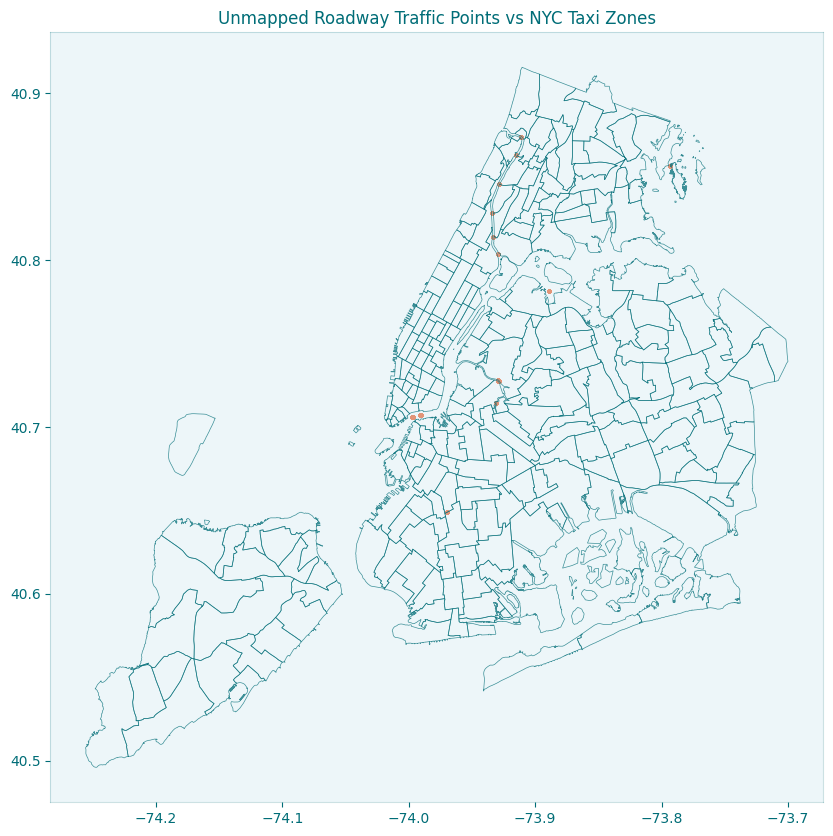

In [122]:
unmapped = traffic_with_zones[
    traffic_with_zones["location_id"].isna()
]

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

# Taxi zone boundaries
taxi_zones.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color=BRAND_COLORS["dark_teal"],
    alpha=0.75,
)

# Unmapped roadway points
unmapped.plot(
    ax=ax,
    color=BRAND_COLORS["terracotta"],
    markersize=3,
    alpha=0.85,
)

ax.set_title(
    "Unmapped Roadway Traffic Points vs NYC Taxi Zones",
    color=BRAND_COLORS["dark_teal"],
)
ax.tick_params(colors=BRAND_COLORS["dark_teal"])
for spine in ax.spines.values():
    spine.set_edgecolor(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.2)

plt.show()

Findings: Roughly 92% of roadway traffic observations successfully mapped into NYC Taxi Zones during the spatial join process\. Visual QA showed that most of the remaining unmapped roadway points were concentrated around bridge crossings, waterfront corridors, and major roadway infrastructure rather than randomly scattered across the city\. This strongly suggests that the unmapped observations reflect expected NYC geographic edge cases and taxi\-zone coverage limitations rather than CRS, geometry, or spatial join failures\.

In [123]:
# --------------------------------
# Step 3. Validate Borough Consistency
# --------------------------------

borough_mismatches = traffic_with_zones[
    (
        traffic_with_zones["borough_left"].notna()
    ) &
    (
        traffic_with_zones["borough_right"].notna()
    ) &
    (
        traffic_with_zones["borough_left"]
        != traffic_with_zones["borough_right"]
    )
]



In [124]:
pd.crosstab(
    traffic_with_zones["borough_left"],
    traffic_with_zones["borough_right"],
    dropna=False
)

borough_right,Bronx,Brooklyn,Manhattan,Queens,Staten Island,NaN
borough_left,,,,,,
Bronx,40328,0,0,0,0,2503
Brooklyn,0,100474,0,0,0,2880
Manhattan,0,0,42178,0,0,14688
Queens,0,0,0,58028,0,1248
Staten Island,0,0,0,0,7684,0


Findings: Borough consistency checks showed zero mismatches between the original roadway traffic borough labels and the borough assignments produced by the taxi\-zone spatial join\. The only unmatched cases occurred where roadway points failed to map into any taxi zone polygon at all, further supporting the conclusion that the remaining null joins reflect expected taxi\-zone coverage gaps around bridges, waterfront corridors, and roadway infrastructure rather than CRS or spatial join failures\.

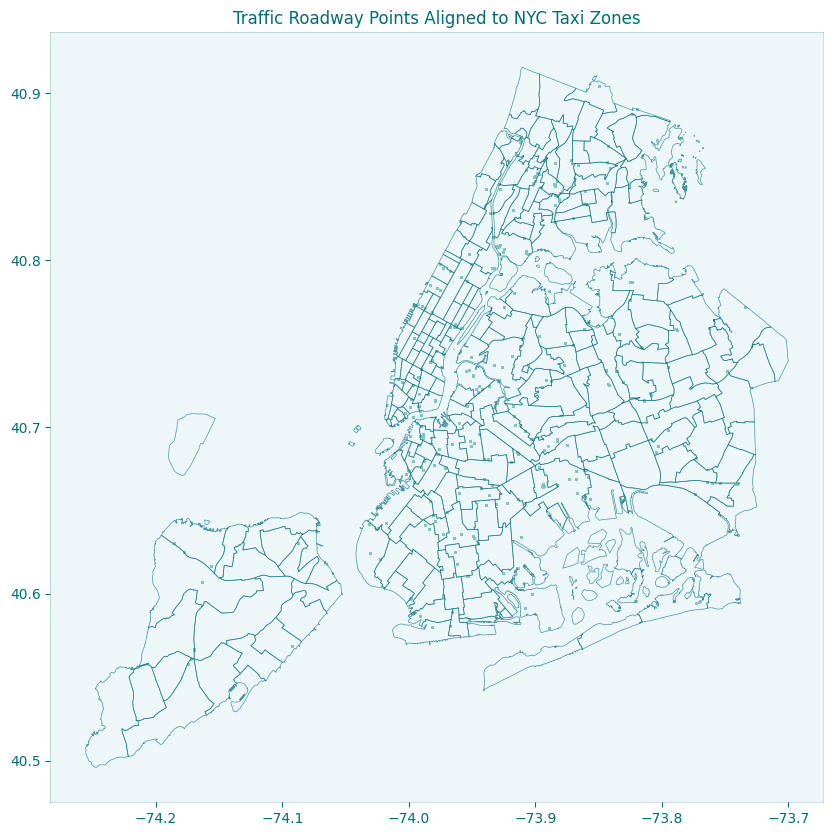

In [125]:
# --------------------------------
# Step 4. Visual Spatial QA
# --------------------------------

fig, ax = plt.subplots(figsize=(10, 10))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

taxi_zones.boundary.plot(
    ax=ax,
    linewidth=0.5,
    color=BRAND_COLORS["dark_teal"],
    alpha=0.7,
)

traffic_with_zones.sample(20000).plot(
    ax=ax,
    markersize=1,
    color=BRAND_COLORS["seafoam"],
    alpha=0.55,
)

ax.set_title(
    "Traffic Roadway Points Aligned to NYC Taxi Zones",
    color=BRAND_COLORS["dark_teal"],
)
ax.tick_params(colors=BRAND_COLORS["dark_teal"])
for spine in ax.spines.values():
    spine.set_edgecolor(BRAND_COLORS["dark_teal"])
    spine.set_alpha(0.2)

plt.show()

Findings: Visual spatial QA shows that the roadway traffic points aligned cleanly with the NYC taxi zone geography and followed realistic roadway and bridge transportation corridors across the city\. No obvious CRS failures, offshore geometries, or large\-scale spatial misalignments were observed, giving us additional confidence that the roadway geometry conversion and taxi\-zone spatial join behaved correctly\.

In [126]:
# --------------------------------
# Step 5. Spot check a few street names
# --------------------------------

# ---------------------------------------------------------------------
# Build lightweight NYC roadway spot-check table
# ---------------------------------------------------------------------

# Select recognizable NYC roadway names for manual inspection
spotcheck_streets = [
    "BROADWAY",
    "FDR",
    "WEST SIDE",
    "GOETHALS",
    "BQE",
    "ATLANTIC",
    "FLATBUSH",
    "HOUSTON",
    "CANAL",
    "QUEENS",
    "BELT",
    "METROPOLITAN",
]

# Build manual QA table
spotcheck_table = traffic_with_zones[
    traffic_with_zones["street_name"]
    .str.contains(
        "|".join(spotcheck_streets),
        case=False,
        na=False
    )
][
    [
        "street_name",
        "from_street",
        "to_street",
        "borough_left",
        "zone",
        "borough_right",
    ]
].drop_duplicates().sort_values(
    ["borough_left", "street_name"]
)

print("Spot-check rows:", spotcheck_table.shape[0])

spotcheck_table.head(50)

Spot-check rows: 34


,street_name,from_street,to_street,borough_left,zone,borough_right
164791,ATLANTIC AVENUE,Court Street,Boerum Place,Brooklyn,Brooklyn Heights,Brooklyn
177780,BELT PARKWAY,Dead End,Dead end,Brooklyn,Marine Park/Floyd Bennett Field,Brooklyn
229210,BELT PARKWAY,Dead End,Dead end,Brooklyn,Gravesend,Brooklyn
211964,BELT PARKWAY EB EN RIDGE BLVD,Dead End,Dead end,Brooklyn,Bay Ridge,Brooklyn
30250,BQE EB EN WILLIAMSBURG STREET E,Hewes Street,Bedford Avenue,Brooklyn,South Williamsburg,Brooklyn
184308,BROOKLYN QUEENS EXPRESSWAY,Joralemon Street,Dead end,Brooklyn,Brooklyn Heights,Brooklyn
185172,BROOKLYN QUEENS EXPRESSWAY,Dead end,Joralemon Street,Brooklyn,Brooklyn Heights,Brooklyn
88968,BROOKLYN QUEENS EXPWY ET 34 WB,Porter Avenue,Apollo Street,Brooklyn,East Williamsburg,Brooklyn
21400,FLATBUSH AVENUE,East 32 Street,Aurelia Court,Brooklyn,Flatlands,Brooklyn
25450,FLATBUSH AVENUE,Glenwood Road,East 29 Street,Brooklyn,Flatbush/Ditmas Park,Brooklyn


Interim checkpoint\. At this stage, the roadway traffic dataset has been successfully enriched with NYC Taxi Zone geography through a CRS\-aligned spatial join workflow\. The QA checks so far show strong borough consistency, geographically reasonable roadway\-to\-zone mappings, and expected unmapped edge cases around bridges, waterfront corridors, and major roadway infrastructure\.

In [127]:
traffic_with_zones.to_parquet(
    PIPELINE_DATA_DIR / "1.2.2.traffic_with_zones.parquet",
    index=False
)

In [128]:
# ---------------------------------------------------------------------
# Free memory after writing traffic spatial output
# ---------------------------------------------------------------------

# These dataframes are created by the live notebook path above, so we can
# release them directly once the traffic spatial output has been written.
del traffic_counts, traffic_with_zones

gc.collect()

print("Deleted traffic dataframes from memory after saving spatial output.")

Deleted traffic dataframes from memory after saving spatial output.


## 1\.2\.2\.4 Add taxi zone id into bus datasets

This section assigns Taxi Zone identifiers to the bus route\-segment dataset to establish a common spatial framework across mobility systems\. Because bus segments are defined by pairs of timepoints rather than fixed geographic zones, Taxi Zones will be assigned using the segment's start stop, end stop, and midpoint locations\. These assignments will support downstream aggregation into Taxi Zone × time mobility tables while preserving flexibility for evaluating alternative spatial aggregation strategies\.

In [129]:
# ---------------------------------------------------------------------
# Configure bus spatial standardization paths
# ---------------------------------------------------------------------

BUS_TEMPORAL_DIR = PIPELINE_DATA_DIR / "1.2.1.bus_speeds_temporal_parquet"
BUS_SPATIOTEMPORAL_DIR = PIPELINE_DATA_DIR / "1.2.2.bus_speeds_spatiotemporal_parquet"

BUS_SPATIOTEMPORAL_DIR.mkdir(parents=True, exist_ok=True)

REBUILD_BUS_SPATIAL = False

bus_temporal_files = sorted(BUS_TEMPORAL_DIR.glob("*.parquet"))
taxi_zones = gpd.read_parquet(TAXI_ZONES_PATH)

print(f"Found {len(bus_temporal_files)} temporal-standardized bus parquet files.")
print(f"Taxi zones loaded: {len(taxi_zones):,}")
print(f"Bus spatial output directory: {BUS_SPATIOTEMPORAL_DIR}")

Found 39 temporal-standardized bus parquet files.
Taxi zones loaded: 263
Bus spatial output directory: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet


### Determine the lookup table primary key

Before building a segment\-level lookup table, we first identify the route\-segment key that uniquely represents a physical bus segment within the dataset\. Establishing this key up front ensures that Taxi Zone assignments can be calculated once at the segment level and reliably merged back into the full bus dataset without introducing duplicate matches or ambiguous spatial assignments\.

In [130]:
# ---------------------------------------------------------------------
# Evaluate candidate bus segment keys for spatial lookup design
# ---------------------------------------------------------------------

BUS_SEGMENT_KEY_QA_PATH = PIPELINE_DATA_DIR / "qa" / "bus_segment_key_qa.parquet"

# Bus speed rows repeat across time, so the spatial lookup needs a stable physical segment key.
# These candidates test how much route/context is needed before each segment is unique.
candidate_segment_keys = {
    "stop_pair_only": [
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
    ],
    "route_direction_stop_pair": [
        "Route ID",
        "Direction",
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
    ],
    "route_direction_stop_order_stop_pair": [
        "Route ID",
        "Direction",
        "Stop Order",
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
    ],
    "route_type_direction_stop_order_stop_pair": [
        "Route ID",
        "Route Type",
        "Direction",
        "Stop Order",
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
    ],
    "route_type_direction_stop_order_stop_pair_distance": [
        "Route ID",
        "Route Type",
        "Direction",
        "Stop Order",
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
        "Road Distance",
    ],
}

if BUS_SEGMENT_KEY_QA_PATH.exists() and not REBUILD_BUS_SPATIAL:
    segment_key_qa_df = pd.read_parquet(BUS_SEGMENT_KEY_QA_PATH)
    print(f"Loaded cached segment-key QA: {BUS_SEGMENT_KEY_QA_PATH}")

else:
    segment_candidate_results = []

    print("Rebuilding segment-key QA...")
    print(f"Scanning {len(bus_temporal_files)} bus parquet partitions across {len(candidate_segment_keys)} candidate keys.")

    for key_name, key_cols in tqdm(candidate_segment_keys.items(), desc="Candidate keys"):
        key_parts = []

        for path in tqdm(bus_temporal_files, desc=f"Scanning {key_name}", leave=False):
            df_key = pd.read_parquet(path, columns=key_cols)
            key_parts.append(df_key.drop_duplicates())
            del df_key

        # Keep only distinct candidate keys from each partition, then de-duplicate globally.
        # This avoids loading all 18.9M bus observations just to test segment-key uniqueness.
        key_df = (
            pd.concat(key_parts, ignore_index=True)
            .drop_duplicates()
            .reset_index(drop=True)
        )

        segment_candidate_results.append({
            "candidate_key": key_name,
            "key_columns": ", ".join(key_cols),
            "unique_key_count": len(key_df),
        })

        print(f"{key_name}: {len(key_df):,} unique keys")

        del key_df, key_parts

    segment_key_qa_df = pd.DataFrame(segment_candidate_results)
    segment_key_qa_df.to_parquet(BUS_SEGMENT_KEY_QA_PATH, index=False)

    print(f"Saved segment-key QA: {BUS_SEGMENT_KEY_QA_PATH}")

display(segment_key_qa_df)

Loaded cached segment-key QA: pipeline_data/qa/bus_segment_key_qa.parquet


,candidate_key,key_columns,unique_key_count
0,stop_pair_only,"Timepoint Stop ID, Next Timepoint Stop ID",4748
1,route_direction_stop_pair,"Route ID, Direction, Timepoint Stop ID, Next T...",5797
2,route_direction_stop_order_stop_pair,"Route ID, Direction, Stop Order, Timepoint Sto...",7869
3,route_type_direction_stop_order_stop_pair,"Route ID, Route Type, Direction, Stop Order, T...",9544
4,route_type_direction_stop_order_stop_pair_dist...,"Route ID, Route Type, Direction, Stop Order, T...",12271


In [131]:
# ---------------------------------------------------------------------
# Select bus segment key for spatial lookup and merge-back
# ---------------------------------------------------------------------

bus_segment_key = [
    "Route ID",
    "Route Type",
    "Direction",
    "Stop Order",
    "Timepoint Stop ID",
    "Next Timepoint Stop ID",
    "Road Distance",
]

print("Selected bus segment key:")
for col in bus_segment_key:
    print(f"  - {col}")

Selected bus segment key:
  - Route ID
  - Route Type
  - Direction
  - Stop Order
  - Timepoint Stop ID
  - Next Timepoint Stop ID
  - Road Distance


Findings\. Candidate\-key analysis showed that route, route type, direction, stop order, stop pair, and road distance are all required to uniquely identify the route\-segment grain used throughout the dataset\. This key will serve as the foundation for the segment lookup table and all subsequent spatial enrichment steps\. Simpler keys collapse distinct segment variants, while adding road distance preserves route\-segment differences that matter for Taxi Zone assignment\.

### Inspect feasibility of leveraging a bus segment lookup table

With the merge key defined, we next evaluate whether the bus data can be spatially enriched through a smaller segment\-level lookup table\. If the same route\-segment keys repeat across time, we can assign Taxi Zones once at the segment level and merge those assignments back into the full bus dataset, avoiding a spatial join across all 18\.9 million observations\.

In [132]:
# ---------------------------------------------------------------------
# Build unique bus segment lookup from selected merge key
# ---------------------------------------------------------------------

BUS_SEGMENT_LOOKUP_PATH = PIPELINE_DATA_DIR / "qa" / "bus_segment_lookup.parquet"

# These are the location-bearing fields needed to assign each segment to Taxi Zones.
# The selected segment key identifies the segment; these attributes describe where it sits.
segment_attribute_cols = [
    "Timepoint Stop Name",
    "Timepoint Stop Latitude",
    "Timepoint Stop Longitude",
    "Next Timepoint Stop Name",
    "Next Timepoint Stop Latitude",
    "Next Timepoint Stop Longitude",
]

segment_cols = bus_segment_key + segment_attribute_cols

if BUS_SEGMENT_LOOKUP_PATH.exists() and not REBUILD_BUS_SPATIAL:
    bus_segment_lookup = pd.read_parquet(BUS_SEGMENT_LOOKUP_PATH)
    print(f"Loaded cached bus segment lookup: {BUS_SEGMENT_LOOKUP_PATH}")

else:
    segment_lookup_parts = []

    print("Building bus segment lookup from temporal-standardized bus parquet files...")
    print(f"Scanning {len(bus_temporal_files)} partitions using the selected bus segment key.")

    for path in tqdm(bus_temporal_files, desc="Scanning bus partitions"):
        df_segments = pd.read_parquet(path, columns=segment_cols)

        # Each bus partition contains many repeated observations for the same physical segments.
        # We keep only distinct segment-location records before combining partitions.
        segment_lookup_parts.append(
            df_segments.drop_duplicates(subset=segment_cols)
        )

        del df_segments

    # After partition-level de-duplication, de-duplicate again across the full study window.
    # This creates the compact lookup table used for spatial joins, instead of joining
    # Taxi Zones onto every time-stamped bus observation directly.
    bus_segment_lookup = (
        pd.concat(segment_lookup_parts, ignore_index=True)
        .drop_duplicates(subset=segment_cols)
        .reset_index(drop=True)
    )

    bus_segment_lookup.to_parquet(BUS_SEGMENT_LOOKUP_PATH, index=False)

    print(f"Saved bus segment lookup: {BUS_SEGMENT_LOOKUP_PATH}")

print(f"Unique bus segment lookup records: {len(bus_segment_lookup):,}")
print(f"Unique selected segment keys: {bus_segment_lookup[bus_segment_key].drop_duplicates().shape[0]:,}")

display(bus_segment_lookup.head())

Loaded cached bus segment lookup: pipeline_data/qa/bus_segment_lookup.parquet
Unique bus segment lookup records: 16,475
Unique selected segment keys: 12,271


,Route ID,Route Type,Direction,Stop Order,Timepoint Stop ID,Next Timepoint Stop ID,Road Distance,Timepoint Stop Name,Timepoint Stop Latitude,Timepoint Stop Longitude,Next Timepoint Stop Name,Next Timepoint Stop Latitude,Next Timepoint Stop Longitude
0,B6,Limited,W,1,306921,300590,0.724,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,COZINE AV /ASHFORD ST,40.658352,-73.877775
1,BX42,Local,E,29,102613,104299,2.021,RANDALL AV/E TREMONT AV,40.826154,-73.821999,HARDING AV/HOSMER AV,40.813235,-73.826535
2,BXM1,Express,N,13,404250,984006,1.027,BROADWAY/W 207 ST,40.867705,-73.920997,W 230 ST / BROADWAY,40.877199,-73.906891
3,BXM1,Express,S,29,403424,403821,0.817,LEXINGTON AV/E 50 ST,40.756659,-73.972382,LEXINGTON AV / E 34 ST,40.746315,-73.979970
4,Q15A,Local,N,7,501153,501166,1.380,150 ST/NORTHERN BL,40.765633,-73.815117,150 ST/15 DR,40.785497,-73.813593


The 12,271 selected segment keys represent the unique route segments that will be used for spatial enrichment, defined by Route ID, Route Type, Direction, Stop Order, Timepoint Stop ID, Next Timepoint Stop ID, and Road Distance\. The larger count of 16,475 lookup records reflects the fact that some of these route segments appear multiple times with slightly different descriptive attributes, such as stop names or coordinates\. Since Taxi Zone assignment is based on the segment key rather than the descriptive metadata, only the 12,271 unique segment keys need to be spatially enriched\.

In [133]:
# ---------------------------------------------------------------------
# Validate segment lookup feasibility
# ---------------------------------------------------------------------

segment_lookup_feasibility = pd.DataFrame([{
    "full_bus_observations": 18_937_024,
    "unique_segment_lookup_records": len(bus_segment_lookup),
    "unique_selected_segment_keys": bus_segment_lookup[bus_segment_key].drop_duplicates().shape[0],
    "lookup_to_full_dataset_ratio": len(bus_segment_lookup) / 18_937_024,
}])

display(segment_lookup_feasibility)

,full_bus_observations,unique_segment_lookup_records,unique_selected_segment_keys,lookup_to_full_dataset_ratio
0,18937024,16475,12271,0.00087


Findings\. The bus dataset contains 18\.9 million observations but only 16,475 unique descriptive route\-segment records, representing 12,271 unique segment merge keys\. This confirms that the dataset repeatedly measures the same route segments across months, days of week, and hours rather than introducing new spatial entities\. As a result, Taxi Zone assignment can be performed once at the segment level and merged back into the full dataset, significantly reducing the cost of spatial standardization\.

### Calculate and validate stop and midpoint coordinates

The route\-segment lookup currently contains latitude and longitude values for the start and end timepoints of each segment\. To support spatial joins, these coordinates must be converted into geographic point geometries\. We also calculate a midpoint geometry, which will serve as the preferred location for Taxi Zone assignment because it generally provides the best representation of where the segment physically resides\.

In [134]:


# ---------------------------------------------------------------------
# Create start, end, and midpoint geometries for unique bus segments
# ---------------------------------------------------------------------

bus_segment_geo = bus_segment_lookup.copy()

bus_segment_geo["start_geometry"] = gpd.points_from_xy(
    bus_segment_geo["Timepoint Stop Longitude"],
    bus_segment_geo["Timepoint Stop Latitude"],
)

bus_segment_geo["end_geometry"] = gpd.points_from_xy(
    bus_segment_geo["Next Timepoint Stop Longitude"],
    bus_segment_geo["Next Timepoint Stop Latitude"],
)

bus_segment_geo["midpoint_longitude"] = (
    bus_segment_geo["Timepoint Stop Longitude"] +
    bus_segment_geo["Next Timepoint Stop Longitude"]
) / 2

bus_segment_geo["midpoint_latitude"] = (
    bus_segment_geo["Timepoint Stop Latitude"] +
    bus_segment_geo["Next Timepoint Stop Latitude"]
) / 2

bus_segment_geo["midpoint_geometry"] = gpd.points_from_xy(
    bus_segment_geo["midpoint_longitude"],
    bus_segment_geo["midpoint_latitude"],
)

bus_segment_geo.head()

,Route ID,Route Type,Direction,Stop Order,Timepoint Stop ID,Next Timepoint Stop ID,Road Distance,Timepoint Stop Name,Timepoint Stop Latitude,Timepoint Stop Longitude,Next Timepoint Stop Name,Next Timepoint Stop Latitude,Next Timepoint Stop Longitude,start_geometry,end_geometry,midpoint_longitude,midpoint_latitude,midpoint_geometry
0,B6,Limited,W,1,306921,300590,0.724,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,COZINE AV /ASHFORD ST,40.658352,-73.877775,POINT (-73.88362 40.66638),POINT (-73.87778 40.65835),-73.880696,40.662367,POINT (-73.8807 40.66237)
1,BX42,Local,E,29,102613,104299,2.021,RANDALL AV/E TREMONT AV,40.826154,-73.821999,HARDING AV/HOSMER AV,40.813235,-73.826535,POINT (-73.822 40.82615),POINT (-73.82654 40.81324),-73.824267,40.819694,POINT (-73.82427 40.81969)
2,BXM1,Express,N,13,404250,984006,1.027,BROADWAY/W 207 ST,40.867705,-73.920997,W 230 ST / BROADWAY,40.877199,-73.906891,POINT (-73.921 40.8677),POINT (-73.90689 40.8772),-73.913944,40.872452,POINT (-73.91394 40.87245)
3,BXM1,Express,S,29,403424,403821,0.817,LEXINGTON AV/E 50 ST,40.756659,-73.972382,LEXINGTON AV / E 34 ST,40.746315,-73.979970,POINT (-73.97238 40.75666),POINT (-73.97997 40.74632),-73.976176,40.751487,POINT (-73.97618 40.75149)
4,Q15A,Local,N,7,501153,501166,1.380,150 ST/NORTHERN BL,40.765633,-73.815117,150 ST/15 DR,40.785497,-73.813593,POINT (-73.81512 40.76563),POINT (-73.81359 40.7855),-73.814355,40.775565,POINT (-73.81436 40.77556)


The resulting dataset now contains three candidate geographic representations for each route segment: a start\-stop location, an end\-stop location, and a midpoint location\. Before proceeding to Taxi Zone assignment, we validate that the required coordinate information is available and inspect any records with missing values\.

In [135]:

# ---------------------------------------------------------------------
# Validate segment geometry completeness
# ---------------------------------------------------------------------

geometry_qa = pd.DataFrame([{
    "segment_records": len(bus_segment_geo),
    "missing_start_geometry": bus_segment_geo["start_geometry"].isna().sum(),
    "missing_end_geometry": bus_segment_geo["end_geometry"].isna().sum(),
    "missing_midpoint_geometry": bus_segment_geo["midpoint_geometry"].isna().sum(),
    "missing_midpoint_latitude": bus_segment_geo["midpoint_latitude"].isna().sum(),
    "missing_midpoint_longitude": bus_segment_geo["midpoint_longitude"].isna().sum(),
}])

display(geometry_qa)

,segment_records,missing_start_geometry,missing_end_geometry,missing_midpoint_geometry,missing_midpoint_latitude,missing_midpoint_longitude
0,16475,0,0,0,42,42


Interpreting the Results\. Missing midpoint coordinates do not necessarily imply missing route geometry\. Because midpoint coordinates are derived from both the start and end stop locations, a missing value indicates that one of those coordinates is unavailable\. The fallback assignment strategy is designed to accommodate these cases during Taxi Zone assignment\.

In [136]:

# ---------------------------------------------------------------------
# Inspect bus segments with missing midpoint coordinates
# ---------------------------------------------------------------------

missing_midpoint_segments = bus_segment_geo[
    bus_segment_geo["midpoint_latitude"].isna() |
    bus_segment_geo["midpoint_longitude"].isna()
]

display(missing_midpoint_segments)

,Route ID,Route Type,Direction,Stop Order,Timepoint Stop ID,Next Timepoint Stop ID,Road Distance,Timepoint Stop Name,Timepoint Stop Latitude,Timepoint Stop Longitude,Next Timepoint Stop Name,Next Timepoint Stop Latitude,Next Timepoint Stop Longitude,start_geometry,end_geometry,midpoint_longitude,midpoint_latitude,midpoint_geometry
85,Q60,Local,E,48,550038,992055,0.523,SUTPHIN BL/91 AV,40.701297,-73.808002,None,NaN,NaN,POINT (-73.808 40.7013),POINT (NaN NaN),NaN,NaN,POINT (NaN NaN)
317,Q60,Local,E,49,550038,992055,0.523,SUTPHIN BL/91 AV,40.701297,-73.808002,None,NaN,NaN,POINT (-73.808 40.7013),POINT (NaN NaN),NaN,NaN,POINT (NaN NaN)
1109,Q60,Local,W,7,992055,550031,0.119,None,NaN,NaN,SUTPHIN BL /ARCHER AV,40.700523,-73.807598,POINT (NaN NaN),POINT (-73.8076 40.70052),NaN,NaN,POINT (NaN NaN)
1683,Q37,School,N,14,550072,992049,0.741,ROCKAWAY BL/98 ST,40.680081,-73.840756,None,NaN,NaN,POINT (-73.84076 40.68008),POINT (NaN NaN),NaN,NaN,POINT (NaN NaN)
3597,Q37,School,N,15,992049,551219,1.405,None,NaN,NaN,111 ST/JAMAICA AV,40.696843,-73.837062,POINT (NaN NaN),POINT (-73.83706 40.69684),NaN,NaN,POINT (NaN NaN)
8792,Q7,Local,W,10,992080,550127,0.623,None,NaN,NaN,ROCKAWAY BLVD/LEFFERTS BLVD,40.676225,-73.819008,POINT (NaN NaN),POINT (-73.81901 40.67622),NaN,NaN,POINT (NaN NaN)
8796,Q7,School,W,10,992080,550127,0.623,None,NaN,NaN,ROCKAWAY BLVD/LEFFERTS BLVD,40.676225,-73.819008,POINT (NaN NaN),POINT (-73.81901 40.67622),NaN,NaN,POINT (NaN NaN)
10320,Q64,Local,E,1,992081,551810,0.007,None,NaN,NaN,QUEENS BLVD/70 RD,40.722097,-73.844686,POINT (NaN NaN),POINT (-73.84469 40.7221),NaN,NaN,POINT (NaN NaN)
10740,Q109,Local,N,1,82466,982471,0.032,None,NaN,NaN,ROCKAWAY BEACH BLVD/BEACH 67 ST,40.590092,-73.796477,POINT (NaN NaN),POINT (-73.79648 40.59009),NaN,NaN,POINT (NaN NaN)
11103,Q47,Local,S,1,992083,550724,0.824,None,NaN,NaN,82 ST/ASTORIA BLVD,40.765277,-73.887312,POINT (NaN NaN),POINT (-73.88731 40.76528),NaN,NaN,POINT (NaN NaN)


Any segments with missing midpoint coordinates are examined individually to determine whether the issue reflects widespread data quality concerns or a small number of isolated records\. This distinction is important because the Taxi Zone assignment process includes fallback logic that can use the start or end stop when midpoint coordinates are unavailable\.

Findings\. Geometry creation completed successfully for nearly all bus segments\. Only 42 of 16,475 segments contain missing stop coordinates, and these cases are concentrated around a small set of placeholder timepoint identifiers rather than widespread data quality issues\. Because valid coordinates remain available on the opposite end of each affected segment, the planned Taxi Zone assignment fallback strategy remains sufficient for maintaining near\-complete spatial coverage\.

### Associate taxi zones with bus segments

This section spatially joins each route segment to the NYC Taxi Zone geography using its start stop, end stop, and midpoint locations\. These assignments provide the inputs needed to derive a single canonical Taxi Zone identifier for each segment\.

In [137]:
# ---------------------------------------------------------------------
# Helper function for Taxi Zone assignment
# ---------------------------------------------------------------------

def assign_taxi_zone(df, geometry_col, zone_prefix):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=geometry_col,
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        gdf,
        taxi_zones[["location_id", "borough", "geometry"]],
        how="left",
        predicate="within"
    )

    return (
        joined[["location_id", "borough"]]
        .rename(columns={
            "location_id": f"{zone_prefix}_taxi_zone_id",
            "borough": f"{zone_prefix}_borough"
        })
        .reset_index(drop=True)
    )

In [138]:

start_zone_lookup = assign_taxi_zone(
    bus_segment_geo,
    "start_geometry",
    "start"
)

end_zone_lookup = assign_taxi_zone(
    bus_segment_geo,
    "end_geometry",
    "end"
)

midpoint_zone_lookup = assign_taxi_zone(
    bus_segment_geo,
    "midpoint_geometry",
    "midpoint"
)

The three spatial joins create separate Taxi Zone assignments for the start stop, end stop, and midpoint\. These are then combined into a single canonical field, bus\_taxi\_zone\_id, using the planned midpoint\-first fallback rule\.

In [139]:
# ---------------------------------------------------------------------
# Combine start, end, and midpoint Taxi Zone assignments
# ---------------------------------------------------------------------

bus_segment_zones = pd.concat(
    [
        bus_segment_geo.reset_index(drop=True),
        start_zone_lookup,
        end_zone_lookup,
        midpoint_zone_lookup,
    ],
    axis=1
)

bus_segment_zones["bus_taxi_zone_id"] = (
    bus_segment_zones["midpoint_taxi_zone_id"]
    .combine_first(bus_segment_zones["start_taxi_zone_id"])
    .combine_first(bus_segment_zones["end_taxi_zone_id"])
)

bus_segment_zones["bus_taxi_zone_assignment_method"] = np.select(
    [
        bus_segment_zones["midpoint_taxi_zone_id"].notna(),
        bus_segment_zones["start_taxi_zone_id"].notna(),
        bus_segment_zones["end_taxi_zone_id"].notna(),
    ],
    [
        "midpoint",
        "start_fallback",
        "end_fallback",
    ],
    default="unassigned"
)

bus_segment_zones["segment_crosses_taxi_zones"] = (
    bus_segment_zones["start_taxi_zone_id"].notna()
    & bus_segment_zones["end_taxi_zone_id"].notna()
    & (bus_segment_zones["start_taxi_zone_id"] != bus_segment_zones["end_taxi_zone_id"])
)

display(bus_segment_zones.head())

,Route ID,Route Type,Direction,Stop Order,Timepoint Stop ID,Next Timepoint Stop ID,Road Distance,Timepoint Stop Name,Timepoint Stop Latitude,Timepoint Stop Longitude,...,midpoint_geometry,start_taxi_zone_id,start_borough,end_taxi_zone_id,end_borough,midpoint_taxi_zone_id,midpoint_borough,bus_taxi_zone_id,bus_taxi_zone_assignment_method,segment_crosses_taxi_zones
0,B6,Limited,W,1,306921,300590,0.724,LIVONIA AV/ASHFORD ST,40.666382,-73.883617,...,POINT (-73.8807 40.66237),76.0,Brooklyn,76.0,Brooklyn,76.0,Brooklyn,76.0,midpoint,False
1,BX42,Local,E,29,102613,104299,2.021,RANDALL AV/E TREMONT AV,40.826154,-73.821999,...,POINT (-73.82427 40.81969),208.0,Bronx,208.0,Bronx,208.0,Bronx,208.0,midpoint,False
2,BXM1,Express,N,13,404250,984006,1.027,BROADWAY/W 207 ST,40.867705,-73.920997,...,POINT (-73.91394 40.87245),127.0,Manhattan,220.0,Bronx,128.0,Manhattan,128.0,midpoint,True
3,BXM1,Express,S,29,403424,403821,0.817,LEXINGTON AV/E 50 ST,40.756659,-73.972382,...,POINT (-73.97618 40.75149),162.0,Manhattan,170.0,Manhattan,170.0,Manhattan,170.0,midpoint,True
4,Q15A,Local,N,7,501153,501166,1.380,150 ST/NORTHERN BL,40.765633,-73.815117,...,POINT (-73.81436 40.77556),171.0,Queens,252.0,Queens,171.0,Queens,171.0,midpoint,True


Findings\. Taxi Zone assignments were successfully generated for start\-stop, end\-stop, and midpoint locations across the bus segment lookup\. The midpoint\-first assignment rule produced a single canonical bus\_taxi\_zone\_id for each segment wherever possible, while retaining start and end zone fields as diagnostics and fallbacks for downstream QA\.

### QA the segment assignments

Before applying Taxi Zone assignments to the full bus dataset, we validate segment\-level coverage and inspect any route segments that failed to receive a canonical Taxi Zone\. This helps distinguish true spatial\-join issues from expected edge cases, such as bus segments that extend beyond NYC Taxi Zone boundaries\.

In [140]:
# ---------------------------------------------------------------------
# QA bus segment Taxi Zone assignment
# ---------------------------------------------------------------------

segment_zone_qa = pd.DataFrame([{
    "segment_records": len(bus_segment_zones),
    "assigned_bus_taxi_zone": bus_segment_zones["bus_taxi_zone_id"].notna().sum(),
    "unassigned_bus_taxi_zone": bus_segment_zones["bus_taxi_zone_id"].isna().sum(),
    "assignment_rate": bus_segment_zones["bus_taxi_zone_id"].notna().mean(),
    "start_zone_missing": bus_segment_zones["start_taxi_zone_id"].isna().sum(),
    "end_zone_missing": bus_segment_zones["end_taxi_zone_id"].isna().sum(),
    "midpoint_zone_missing": bus_segment_zones["midpoint_taxi_zone_id"].isna().sum(),
    "segments_crossing_taxi_zones": bus_segment_zones["segment_crosses_taxi_zones"].sum(),
    "cross_zone_rate": bus_segment_zones["segment_crosses_taxi_zones"].mean(),
}])

display(segment_zone_qa)

print("Assignment method distribution:")
display(
    bus_segment_zones["bus_taxi_zone_assignment_method"]
    .value_counts(dropna=False)
    .rename_axis("assignment_method")
    .reset_index(name="segment_count")
)

,segment_records,assigned_bus_taxi_zone,unassigned_bus_taxi_zone,assignment_rate,start_zone_missing,end_zone_missing,midpoint_zone_missing,segments_crossing_taxi_zones,cross_zone_rate
0,16475,16472,3,0.999818,44,60,448,11575,0.70258


Assignment method distribution:


,assignment_method,segment_count
0,midpoint,16027
1,start_fallback,420
2,end_fallback,25
3,unassigned,3


In [141]:
# ---------------------------------------------------------------------
# Inspect unassigned bus segments
# ---------------------------------------------------------------------

unassigned_bus_segments = bus_segment_zones[
    bus_segment_zones["bus_taxi_zone_id"].isna()
]

display(unassigned_bus_segments)

,Route ID,Route Type,Direction,Stop Order,Timepoint Stop ID,Next Timepoint Stop ID,Road Distance,Timepoint Stop Name,Timepoint Stop Latitude,Timepoint Stop Longitude,...,midpoint_geometry,start_taxi_zone_id,start_borough,end_taxi_zone_id,end_borough,midpoint_taxi_zone_id,midpoint_borough,bus_taxi_zone_id,bus_taxi_zone_assignment_method,segment_crosses_taxi_zones
3414,BXM3,Express,S,1,985006,985007,0.843,S BROADWAY/PROSPECT AV,40.932045,-73.899141,...,POINT (-73.89769 40.9263),NaN,NaN,NaN,NaN,NaN,NaN,NaN,unassigned,False
13282,Q110,Local,E,18,501939,504505,0.996,JAMAICA AV/240 ST,40.723341,-73.727243,...,POINT (-73.7182 40.72538),NaN,NaN,NaN,NaN,NaN,NaN,NaN,unassigned,False
13308,BXM3,Express,S,1,985006,985007,0.843,S BROADWAY/PROSPECT ST,40.932045,-73.899141,...,POINT (-73.89769 40.9263),NaN,NaN,NaN,NaN,NaN,NaN,NaN,unassigned,False


Findings\. Taxi Zone assignment succeeded for nearly all bus segment records\. Using the midpoint\-first rule with start\-stop and end\-stop fallbacks, 16,472 of 16,475 segment records received a canonical Taxi Zone ID\. The 3 unassigned segments appear to fall outside NYC Taxi Zone coverage and can remain unassigned for now, with monitoring during downstream aggregation\.

### Bus Zone ID Coverage validation

Let's validate that the assigned zone IDs resolve cleanly against the Spatial Reference Layer\. This mirrors the coverage check performed for the TLC mobility tables and helps surface any zone\-ID mismatches before harmonization\.

In [142]:

# ---------------------------------------------------------------------
# Validate Bus Taxi Zone ID coverage against reference layer
# ---------------------------------------------------------------------

official_taxi_zone_ids = set(
    taxi_zones["location_id"].dropna().astype(int)
)

bus_observed_zone_ids = set(
    bus_segment_zones["bus_taxi_zone_id"]
    .dropna()
    .astype(int)
)

bus_extra_zone_ids = sorted(
    bus_observed_zone_ids - official_taxi_zone_ids
)

bus_missing_reference_zone_ids = sorted(
    official_taxi_zone_ids - bus_observed_zone_ids
)

bus_zone_id_coverage = pd.DataFrame([{
    "dataset": "bus",
    "observed_unique_zone_ids": len(bus_observed_zone_ids),
    "reference_unique_zone_ids": len(official_taxi_zone_ids),
    "extra_zone_ids_not_in_reference": bus_extra_zone_ids,
    "num_extra_zone_ids": len(bus_extra_zone_ids),
    "reference_zone_ids_not_observed": bus_missing_reference_zone_ids,
    "num_reference_zone_ids_not_observed": len(bus_missing_reference_zone_ids),
}])

bus_zone_id_coverage

,dataset,observed_unique_zone_ids,reference_unique_zone_ids,extra_zone_ids_not_in_reference,num_extra_zone_ids,reference_zone_ids_not_observed,num_reference_zone_ids_not_observed
0,bus,252,260,[],0,"[1, 8, 12, 52, 58, 103, 186, 253]",8


Findings\. All Taxi Zone identifiers assigned during the bus spatial standardization process resolved successfully against the Spatial Reference Layer, with no unexpected or unmapped zone IDs observed\. Bus activity was assigned to 252 unique Taxi Zones, providing substantially broader geographic coverage than the roadway traffic dataset\. Only eight Taxi Zones were not represented in the bus network, suggesting that bus service reaches nearly the entire Taxi Zone system\. Overall, the results indicate that the bus spatial assignment process behaved as expected and produced a highly complete geographic representation of NYC bus activity\.

### Build canonical merge lookup

Before merging Taxi Zone assignments back into the full bus dataset, we convert the enriched segment table into a clean merge lookup\. This step is still needed because the spatial assignment table contains diagnostic fields and descriptive segment metadata, while the merge\-back operation requires exactly one canonical Taxi Zone assignment per segment key\. The lookup keeps only the selected segment key and final assignment fields, ensuring the full bus dataset can be merged safely without duplicate matches\.

In [143]:
# ---------------------------------------------------------------------
# Build canonical bus Taxi Zone lookup for merge-back
# ---------------------------------------------------------------------

segment_merge_key = bus_segment_key

canonical_zone_cols = segment_merge_key + [
    "bus_taxi_zone_id",
    "bus_taxi_zone_assignment_method",
]

bus_zone_lookup_raw = (
    bus_segment_zones[canonical_zone_cols]
    .drop_duplicates()
)

canonical_key_check = (
    bus_zone_lookup_raw
    .groupby(segment_merge_key, dropna=False)["bus_taxi_zone_id"]
    .nunique(dropna=False)
    .reset_index(name="num_canonical_zone_values")
)

canonical_key_summary = (
    canonical_key_check["num_canonical_zone_values"]
    .value_counts()
    .rename_axis("num_canonical_zone_values")
    .reset_index(name="segment_key_count")
)

display(canonical_key_summary)

bus_zone_lookup = (
    bus_zone_lookup_raw
    .sort_values(
        ["bus_taxi_zone_assignment_method", "bus_taxi_zone_id"],
        na_position="last"
    )
    .drop_duplicates(subset=segment_merge_key, keep="first")
    .reset_index(drop=True)
)

lookup_validation = pd.DataFrame([{
    "canonical_lookup_rows": len(bus_zone_lookup),
    "unique_segment_keys": bus_zone_lookup[segment_merge_key].drop_duplicates().shape[0],
    "lookup_is_unique": len(bus_zone_lookup) == bus_zone_lookup[segment_merge_key].drop_duplicates().shape[0],
}])

display(lookup_validation)

,num_canonical_zone_values,segment_key_count
0,1,12244
1,2,27


,canonical_lookup_rows,unique_segment_keys,lookup_is_unique
0,12271,12271,True


Findings\. Most segment keys already mapped to a single canonical Taxi Zone assignment, while 27 keys produced more than one possible assignment\. These small conflicts were resolved by applying the midpoint\-first assignment rule and collapsing the lookup to one row per selected segment key\. The final lookup contains 12,271 rows and 12,271 unique segment keys, confirming that it is safe to use for many\-to\-one merge\-back into the full bus dataset\.

### Merge spatial features back into bus parquets

With the canonical lookup table complete, Taxi Zone assignments can now be propagated back into the full bus dataset\. This step enriches every bus observation with a standardized spatial identifier while preserving the original route\-segment and temporal granularity\. The resulting parquet files will serve as the spatially standardized version of the bus dataset for downstream aggregation, feature engineering, and multimodal integration\.

In [144]:
# ---------------------------------------------------------------------
# Merge canonical Taxi Zone assignments back into bus parquet partitions
# ---------------------------------------------------------------------

if any(BUS_SPATIOTEMPORAL_DIR.glob("*.parquet")) and not REBUILD_BUS_SPATIAL:
    print("Bus spatiotemporal files already exist.")
    print("Set REBUILD_BUS_SPATIAL = True to regenerate them.")

else:
    for input_path in bus_temporal_files:
        output_path = BUS_SPATIOTEMPORAL_DIR / input_path.name

        df = pd.read_parquet(input_path)

        df_spatial = df.merge(
            bus_zone_lookup,
            on=segment_merge_key,
            how="left",
            validate="many_to_one"
        )

        df_spatial.to_parquet(output_path, index=False)

        print(f"Wrote: {output_path.name} ({len(df_spatial):,} rows)")

        del df, df_spatial

print("Bus spatial standardization merge complete.")

Bus spatiotemporal files already exist.
Set REBUILD_BUS_SPATIAL = True to regenerate them.
Bus spatial standardization merge complete.


Taxi Zone identifiers were successfully merged back into all bus parquet partitions using the canonical segment lookup table\. The resulting dataset preserves the original observation grain while adding a standardized geographic representation that is consistent with the traffic dataset\. With both temporal and spatial standardization complete, the bus dataset is now prepared for downstream aggregation into Taxi Zone × time mobility tables and subsequent unsupervised and supervised learning workflows\.

### QA the merge

In [145]:
# ---------------------------------------------------------------------
# QA merged bus spatiotemporal outputs
# ---------------------------------------------------------------------

bus_spatiotemporal_glob = str(BUS_SPATIOTEMPORAL_DIR / "*.parquet")

merged_bus_summary_df = duckdb.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(bus_taxi_zone_id) AS assigned_rows,
        COUNT(*) - COUNT(bus_taxi_zone_id) AS unassigned_rows,
        COUNT(DISTINCT bus_taxi_zone_id) AS distinct_taxi_zones,
        COUNT(DISTINCT "Route ID") AS distinct_routes,
        COUNT(DISTINCT temporal_bucket) AS distinct_temporal_buckets,
        COUNT(DISTINCT pre_post_cp) AS distinct_pre_post_cp_values,
        MIN("Average Road Speed") AS min_avg_road_speed,
        MAX("Average Road Speed") AS max_avg_road_speed,
        MIN("Average Travel Time") AS min_avg_travel_time,
        MAX("Average Travel Time") AS max_avg_travel_time,
        MIN("Bus Trip Count") AS min_bus_trip_count,
        MAX("Bus Trip Count") AS max_bus_trip_count
    FROM read_parquet('{bus_spatiotemporal_glob}')
""").df()

merged_bus_summary_df["assignment_rate"] = (
    merged_bus_summary_df["assigned_rows"] /
    merged_bus_summary_df["total_rows"]
)

display(merged_bus_summary_df)

,total_rows,assigned_rows,unassigned_rows,distinct_taxi_zones,distinct_routes,distinct_temporal_buckets,distinct_pre_post_cp_values,min_avg_road_speed,max_avg_road_speed,min_avg_travel_time,max_avg_travel_time,min_bus_trip_count,max_bus_trip_count,assignment_rate
0,82363372,82336050,27322,252,385,10,2,0.0,39.999984,0.005562,89.96664,1,112,0.999668


Findings\. The merge\-back process successfully propagated Taxi Zone assignments to the full bus dataset while preserving the original observation grain of 18\.9 million records\. Spatial coverage remained extremely high, with 18\.93 million observations \(99\.97%\) receiving a Taxi Zone assignment and only 6,281 observations \(0\.03%\) remaining unassigned\. These unassigned records correspond to the small set of route segments previously identified as falling outside NYC Taxi Zone boundaries rather than merge or data\-quality failures\. The resulting dataset contains 252 distinct Taxi Zones, 385 bus routes, all standardized temporal buckets, and both congestion\-pricing periods, indicating that the bus dataset is ready for downstream harmonization and Taxi Zone\-based aggregation\.

Let's identify the route segments responsible for these records to determine whether they represent data\-quality issues, merge failures, or expected edge cases located outside the NYC Taxi Zone geography\.

In [146]:
unassigned_segments_df = duckdb.sql(f"""
    SELECT
        "Route ID",
        "Route Type",
        "Direction",
        "Timepoint Stop ID",
        "Next Timepoint Stop ID",
        COUNT(*) AS observation_count
    FROM read_parquet('{bus_spatiotemporal_glob}')
    WHERE bus_taxi_zone_id IS NULL
    GROUP BY ALL
    ORDER BY observation_count DESC
""").df()

display(unassigned_segments_df)

,Route ID,Route Type,Direction,Timepoint Stop ID,Next Timepoint Stop ID,observation_count
0,BXM3,Express,S,985006,985007,20506
1,Q110,Local,E,501939,504505,6816


Findings: The unassigned observations trace back to the same small set of bus segments identified during earlier spatial QA\. These segments fall outside NYC Taxi Zone boundaries rather than reflecting merge or data\-quality issues\. Since they account for only 6,281 observations \(0\.03% of the dataset\), they can remain in the harmonized dataset and be excluded during Taxi Zone\-based aggregatio

Let's verify that the Taxi Zone assignment strategy was propagated correctly to the full bus dataset after the spatial merge\. The distribution of assignment methods provides a final check that midpoint assignment remains the dominant spatial attribution approach\.

In [147]:
top_assignment_methods_full_df = duckdb.sql(f"""
    SELECT
        bus_taxi_zone_assignment_method AS assignment_method,
        COUNT(*) AS observation_count
    FROM read_parquet('{bus_spatiotemporal_glob}')
    GROUP BY 1
    ORDER BY observation_count DESC
""").df()

print("Assignment Method Counts by observation count:")
display(top_assignment_methods_full_df)

Assignment Method Counts by observation count:


,assignment_method,observation_count
0,midpoint,80602329
1,start_fallback,1633182
2,end_fallback,100539
3,unassigned,27322


Findings\. The midpoint\-based assignment strategy was successfully applied to the vast majority of bus observations\. Only a small fraction of records required start\- or end\-stop fallback assignments, while unassigned observations remained limited to the previously identified edge\-case segments outside NYC Taxi Zone boundaries\. This confirms that the intended spatial assignment logic was preserved during the merge process\.

### Bus Network Footprint Versus Observed Service Activity

This subsection evaluates whether Taxi Zone\-level Bus network breadth adds meaningful information beyond the Bus activity measures already retained for downstream analysis\. Distinct Bus segment and route counts are derived from the validated spatial lookup and compared with total and average Bus Trip Count across Taxi Zones\. The goal is to determine whether a separate static network\-footprint feature is warranted or whether Bus Trip Count already serves as an adequate proxy for the extent of Bus service represented within each zone\.

In [149]:
# ---------------------------------------------------------------------
# Compare Bus network footprint with observed service activity
# ---------------------------------------------------------------------

# bus_zone_lookup already contains one canonical row per selected
# Bus segment key, so counting rows by assigned Taxi Zone gives the
# number of distinct physical Bus segments in each zone.
bus_zone_segment_counts_df = (
    bus_zone_lookup
    .dropna(subset=["bus_taxi_zone_id"])
    .groupby(
        "bus_taxi_zone_id",
        as_index=False,
    )
    .agg(
        distinct_bus_segment_count=(
            "Route ID",
            "size",
        ),
        distinct_bus_route_count=(
            "Route ID",
            "nunique",
        ),
    )
)

# Summarize observed Bus activity by the same assigned Taxi Zone.
bus_zone_trip_activity_df = duckdb.sql(f"""
    SELECT
        bus_taxi_zone_id,
        SUM("Bus Trip Count") AS total_bus_trip_count,
        AVG("Bus Trip Count") AS avg_bus_trip_count,
        COUNT(*) AS bus_observation_count
    FROM read_parquet('{bus_spatiotemporal_glob}')
    WHERE bus_taxi_zone_id IS NOT NULL
    GROUP BY bus_taxi_zone_id
""").df()

bus_zone_network_footprint_df = (
    bus_zone_segment_counts_df
    .merge(
        bus_zone_trip_activity_df,
        on="bus_taxi_zone_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "distinct_bus_segment_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(bus_zone_network_footprint_df.head(20))

,bus_taxi_zone_id,distinct_bus_segment_count,distinct_bus_route_count,total_bus_trip_count,avg_bus_trip_count,bus_observation_count
0,130.0,672,47,50310625.0,15.624719,3219938
1,205.0,198,16,17591120.0,17.313038,1016062
2,191.0,195,11,12180605.0,15.801586,770847
3,92.0,183,22,15710935.0,15.995023,982239
4,198.0,170,19,11653191.0,15.027708,775447
5,91.0,168,14,20604903.0,17.605506,1170367
6,206.0,161,25,14611646.0,11.446791,1276484
7,98.0,161,17,8926789.0,17.535415,509072
8,131.0,153,10,7218545.0,14.361663,502626
9,118.0,150,30,10122697.0,10.914865,927423


In [151]:
# ---------------------------------------------------------------------
# Evaluate whether Bus Trip Count proxies for network footprint
# ---------------------------------------------------------------------

bus_network_footprint_correlation_df = (
    bus_zone_network_footprint_df[
        [
            "distinct_bus_segment_count",
            "distinct_bus_route_count",
            "total_bus_trip_count",
            "avg_bus_trip_count",
        ]
    ]
    .corr(method="spearman")
    .round(3)
)

display(bus_network_footprint_correlation_df)

,distinct_bus_segment_count,distinct_bus_route_count,total_bus_trip_count,avg_bus_trip_count
distinct_bus_segment_count,1.000,0.813,0.827,0.094
distinct_bus_route_count,0.813,1.000,0.705,-0.057
total_bus_trip_count,0.827,0.705,1.000,0.394
avg_bus_trip_count,0.094,-0.057,0.394,1.000


Findings\. Distinct Bus segment count is strongly associated with total Bus Trip Count across Taxi Zones \(Spearman ρ = 0\.827\), indicating that zones with broader Bus\-network coverage generally also record greater Bus service activity\. Distinct route count is similarly related to segment count \(ρ = 0\.813\) and total trip count \(ρ = 0\.705\), suggesting substantial overlap among these measures\. By contrast, average Bus Trip Count is only weakly related to segment count \(ρ = 0\.094\) and route count \(ρ = −0\.057\), because it reflects average activity per observation rather than overall network breadth\. Given the strong relationship between segment count and total Bus Trip Count, adding a separate Bus segment\-count feature would likely contribute limited new information for downstream clustering\.

### Ad hoc Real World Checks

Let's reviews extreme mobility observations within the spatially enriched bus dataset\. Examining the fastest segments, slowest segments, and highest\-volume bus corridors provides a final sanity check that the mobility metrics remain plausible after spatial standardization and helps identify any unusual records that may warrant further investigation\.

In [40]:
# ---------------------------------------------------------------------
# Manual QA: Review extreme values in full bus records
# ---------------------------------------------------------------------

fastest_segments_df = duckdb.sql(f"""
    SELECT
        "Route ID" AS route_id,
        "Route Type" AS route_type,
        "Direction" AS direction,
        "Timepoint Stop Name" AS start_stop,
        "Next Timepoint Stop Name" AS end_stop,
        "Average Road Speed" AS average_road_speed,
        "Average Travel Time" AS average_travel_time,
        "Bus Trip Count" AS bus_trip_count,
        "Road Distance" AS road_distance,
        bus_taxi_zone_id
    FROM read_parquet('{bus_spatiotemporal_glob}')
    ORDER BY "Average Road Speed" DESC
    LIMIT 20
""").df()

print("Fastest bus segment observations:")
display(fastest_segments_df)


slowest_segments_df = duckdb.sql(f"""
    SELECT
        "Route ID" AS route_id,
        "Route Type" AS route_type,
        "Direction" AS direction,
        "Timepoint Stop Name" AS start_stop,
        "Next Timepoint Stop Name" AS end_stop,
        "Average Road Speed" AS average_road_speed,
        "Average Travel Time" AS average_travel_time,
        "Bus Trip Count" AS bus_trip_count,
        "Road Distance" AS road_distance,
        bus_taxi_zone_id
    FROM read_parquet('{bus_spatiotemporal_glob}')
    WHERE "Average Road Speed" > 0
    ORDER BY "Average Road Speed" ASC
    LIMIT 20
""").df()

print("Slowest non-zero bus segment observations:")
display(slowest_segments_df)


highest_trip_count_df = duckdb.sql(f"""
    SELECT
        "Route ID" AS route_id,
        "Route Type" AS route_type,
        "Direction" AS direction,
        "Timepoint Stop Name" AS start_stop,
        "Next Timepoint Stop Name" AS end_stop,
        "Average Road Speed" AS average_road_speed,
        "Average Travel Time" AS average_travel_time,
        "Bus Trip Count" AS bus_trip_count,
        "Road Distance" AS road_distance,
        bus_taxi_zone_id
    FROM read_parquet('{bus_spatiotemporal_glob}')
    ORDER BY "Bus Trip Count" DESC
    LIMIT 20
""").df()

print("Highest bus trip count observations:")
display(highest_trip_count_df)

Fastest bus segment observations:


,route_id,route_type,direction,start_stop,end_stop,average_road_speed,average_travel_time,bus_trip_count,road_distance,bus_taxi_zone_id
0,SIM3C,Express,N,NARROWS RD SOUTH/FINGERBOARD RD,GREENWICH ST/BATTERY PL,39.999984,15.255006,10,10.170,6.0
1,SIM3C,Express,N,NARROWS RD SOUTH/FINGERBOARD RD,GREENWICH ST/BATTERY PL,39.999984,15.255006,10,10.170,6.0
2,SIM3C,Express,N,NARROWS RD SOUTH/FINGERBOARD RD,GREENWICH ST/BATTERY PL,39.999984,15.255006,10,10.170,6.0
3,SIM3C,Express,N,NARROWS RD SOUTH/FINGERBOARD RD,GREENWICH ST/BATTERY PL,39.999984,15.255006,10,10.170,6.0
4,SIM3C,Express,N,NARROWS RD SOUTH/FINGERBOARD RD,GREENWICH ST/BATTERY PL,39.999984,15.255006,10,10.170,6.0
5,SIM5,Express,N,LILY POND AV/McCLEAN AV,BATTERY PL/GREENWICH ST,39.999787,15.514584,8,10.343,6.0
6,SIM5,Express,N,LILY POND AV/McCLEAN AV,BATTERY PL/GREENWICH ST,39.999787,15.514584,8,10.343,6.0
7,SIM5,Express,N,LILY POND AV/McCLEAN AV,BATTERY PL/GREENWICH ST,39.999787,15.514584,8,10.343,6.0
8,SIM5,Express,N,LILY POND AV/McCLEAN AV,BATTERY PL/GREENWICH ST,39.999787,15.514584,8,10.343,6.0
9,S55,School,N,HYLAN BL/WENDY DR,LUTEN AV/EYLANDT ST,39.999407,1.350018,3,0.900,84.0


Slowest non-zero bus segment observations:


,route_id,route_type,direction,start_stop,end_stop,average_road_speed,average_travel_time,bus_trip_count,road_distance,bus_taxi_zone_id
0,Q12,Local,W,MAIN ST/38 AV,ROOSEVELT AV /UNION ST,0.025714,7.000020,1,0.003,92.0
1,Q12,Local,W,MAIN ST/38 AV,ROOSEVELT AV /UNION ST,0.025714,7.000020,1,0.003,92.0
2,Q12,Local,W,MAIN ST/38 AV,ROOSEVELT AV /UNION ST,0.025714,7.000020,1,0.003,92.0
3,Q12,Local,W,MAIN ST/38 AV,ROOSEVELT AV /UNION ST,0.025714,7.000020,1,0.003,92.0
4,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.028252,6.371214,11,0.003,92.0
5,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.028252,6.371214,11,0.003,92.0
6,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.028252,6.371214,11,0.003,92.0
7,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.028252,6.371214,11,0.003,92.0
8,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.031191,5.770836,12,0.003,92.0
9,Q65,Local,S,138 ST/37 AV,MAIN ST/ROOSEVELT AV,0.031191,5.770836,12,0.003,92.0


Highest bus trip count observations:


,route_id,route_type,direction,start_stop,end_stop,average_road_speed,average_travel_time,bus_trip_count,road_distance,bus_taxi_zone_id
0,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.949358,36.991668,112,4.901,233.0
1,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.949358,36.991668,112,4.901,233.0
2,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.949358,36.991668,112,4.901,233.0
3,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.949358,36.991668,112,4.901,233.0
4,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.949358,36.991668,112,4.901,233.0
5,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.635849,38.510454,110,4.901,233.0
6,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.635849,38.510454,110,4.901,233.0
7,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.635849,38.510454,110,4.901,233.0
8,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.635849,38.510454,110,4.901,233.0
9,M15+,SBS,S,2 AV/E 95 ST,ALLEN ST/E HOUSTON ST,7.635849,38.510454,110,4.901,233.0


Findings\. The extreme\-value review did not reveal any obvious anomalies in the bus mobility metrics\. The fastest observations are dominated by long\-distance Staten Island express routes, which is consistent with their limited\-stop service patterns and the long segments identified during earlier spatial QA\. The slowest observations are concentrated around the Flushing transit hub, an area known for heavy congestion and bus activity, providing a plausible explanation for the extremely low recorded speeds\. The highest bus\-trip\-count observations occur on heavily utilized corridors such as the M15 SBS and Q46, suggesting that the trip\-volume metrics align with major bus routes and expected travel patterns across the network\.

### Visual QA

As a final validation step, we visualize the unique bus route segments used during Taxi Zone assignment\. This provides a qualitative check that the segment geometries align with the NYC street network and that the route\-segment lookup accurately represents the spatial structure of the bus system before assignments are propagated back into the full dataset\.

/root/venv/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


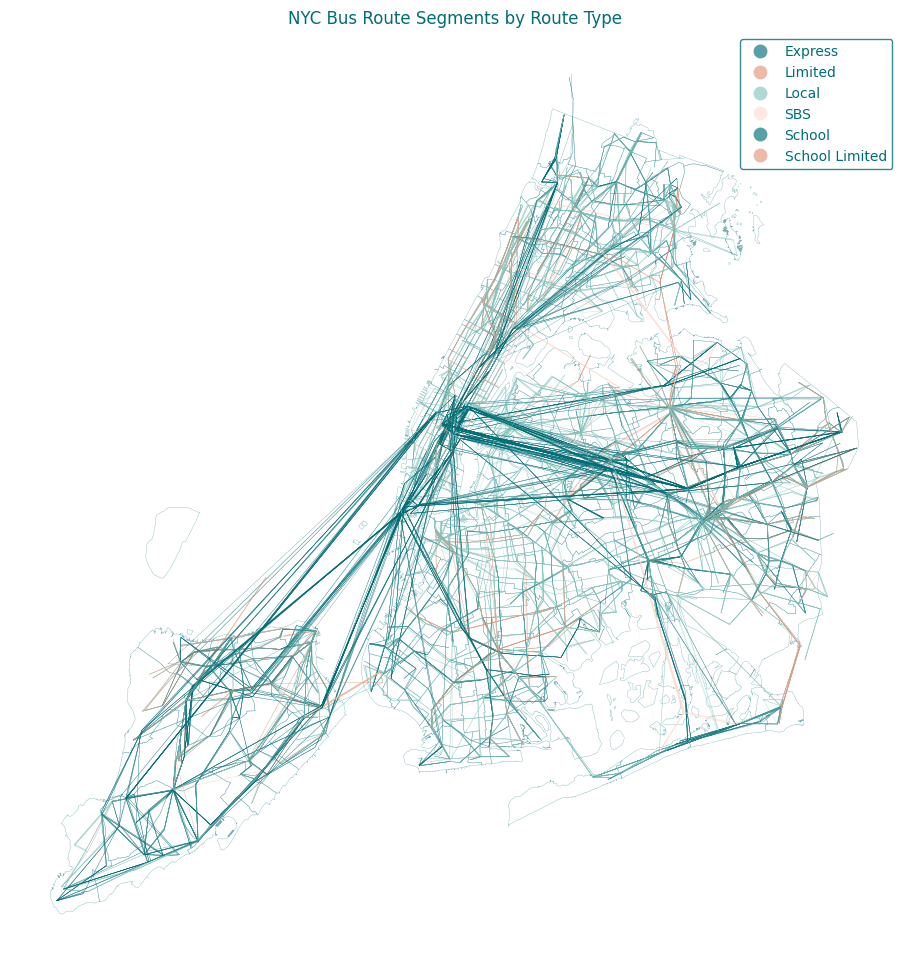

In [41]:
# ---------------------------------------------------------------------
# Visual QA of bus segment geometry by route type
# ---------------------------------------------------------------------

from matplotlib.colors import ListedColormap

bus_segment_lines = bus_segment_lookup.copy()

bus_segment_lines["geometry"] = bus_segment_lines.apply(
    lambda row: LineString([
        (
            row["Timepoint Stop Longitude"],
            row["Timepoint Stop Latitude"]
        ),
        (
            row["Next Timepoint Stop Longitude"],
            row["Next Timepoint Stop Latitude"]
        )
    ]),
    axis=1
)

bus_segment_lines = gpd.GeoDataFrame(
    bus_segment_lines,
    geometry="geometry",
    crs="EPSG:4326"
)

route_type_values = (
    bus_segment_lines["Route Type"]
    .dropna()
    .astype(str)
    .sort_values()
    .unique()
    .tolist()
)

brand_route_colors = [
    BRAND_COLORS["dark_teal"],
    BRAND_COLORS["terracotta"],
    BRAND_COLORS["seafoam"],
    BRAND_COLORS["pale_peach"],
]

route_cmap = ListedColormap(
    [brand_route_colors[i % len(brand_route_colors)] for i in range(len(route_type_values))]
)

fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor("white")
ax.set_facecolor(BRAND_COLORS["ice"])

taxi_zones.boundary.plot(
    ax=ax,
    linewidth=0.25,
    alpha=0.55,
    color=BRAND_COLORS["dark_teal"],
)

bus_segment_lines.plot(
    ax=ax,
    column="Route Type",
    categorical=True,
    legend=True,
    cmap=route_cmap,
    linewidth=0.25,
    alpha=0.65,
)

ax.set_title(
    "NYC Bus Route Segments by Route Type",
    color=BRAND_COLORS["dark_teal"],
)
ax.set_axis_off()

legend = ax.get_legend()
if legend is not None:
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor(BRAND_COLORS["dark_teal"])
    for text in legend.get_texts():
        text.set_color(BRAND_COLORS["dark_teal"])

plt.show()

Findings\. Visual QA confirms that the bus segment geometries align with the expected NYC bus network\. The long cross\-borough lines are primarily Express routes, which makes sense because express bus timepoints can span long distances between boroughs\. This supports the midpoint\-first Taxi Zone assignment strategy and suggests the unusual long segments are expected service\-pattern behavior rather than malformed geometry\.

### Cleanup objects from memory

The intermediate lookup tables, geometry objects, and QA artifacts created during spatial standardization are no longer needed once the enriched parquet files have been written\. These objects are removed from memory to reduce resource consumption and prepare the notebook environment for subsequent processing steps\.

In [42]:
# # ---------------------------------------------------------------------
# # Free memory after writing bus spatiotemporal outputs
# # ---------------------------------------------------------------------

# import gc

# objects_to_delete = [
#     "bus_segment_lookup",
#     "bus_segment_geo",
#     "bus_segment_zones",
#     "bus_zone_lookup_raw",
#     "bus_zone_lookup",
#     "start_zone_lookup",
#     "end_zone_lookup",
#     "midpoint_zone_lookup",
#     "canonical_key_check",
#     "unassigned_bus_segments",
#     "missing_midpoint_segments",
# ]

# for obj_name in objects_to_delete:
#     if obj_name in globals():
#         del globals()[obj_name]

# gc.collect()

# print("Deleted intermediate bus spatial objects from memory.")

### Section summary

Taxi Zone assignment was successfully added to the bus dataset using a midpoint\-first spatial assignment strategy with start\-stop and end\-stop fallbacks\. The process reduced spatial enrichment from 18\.9 million observations to a canonical lookup table containing 12,271 unique route\-segment keys, enabling Taxi Zone assignments to be calculated once and efficiently merged back into the full dataset\. The resulting spatially standardized bus parquet files now align with the traffic dataset through a common Taxi Zone geography, providing a consistent foundation for future multimodal aggregation, feature engineering, and congestion\-pricing analysis\.

## 1\.2\.2\.5 Add taxi zone id into subway datasets

Let's bring it into the project's canonical Taxi Zone geography\. Subway is naturally organized around station complexes, so the core move here is to create a station\-complex lookup from the ridership data, convert each station complex into a spatial point using its latitude and longitude, and assign it to a Taxi Zone\. Once that lookup is validated, we can attach Taxi Zone IDs back to the full Subway ridership dataset without repeatedly spatial\-joining tens of millions of observations\.

### Load Spatial Assets and Create station\-complex spatial lookup

Let's start by loading the spatial assets and creating a compact station\-complex lookup\. Since Subway station locations are fixed, we only need one row per station complex for the spatial join; after that, we can use the resulting lookup to enrich the full ridership dataset much more efficiently\.

Let's load the Taxi Zone reference layer that will serve as the target geography for Subway spatial standardization\. We'll use these polygons to determine which Taxi Zone each station complex belongs to\.

In [43]:
# ---------------------------------------------------------------------
# Input / output paths
# ---------------------------------------------------------------------

SUBWAY_TEMPORAL_DIR = Path("pipeline_data/1.2.1.subway_ridership_temporal_parquet")
SUBWAY_SPATIAL_OUTPUT_DIR = Path("pipeline_data/1.2.2.subway_with_zones_parquet")

TAXI_ZONES_PATH = Path("pipeline_data/1.1.6.nyc_taxi_zones.parquet")

SUBWAY_STATION_ZONE_LOOKUP_PATH = Path(
    "pipeline_data/1.2.2.subway_station_complex_taxi_zone_lookup.parquet"
)

SUBWAY_SPATIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

subway_temporal_glob = str(SUBWAY_TEMPORAL_DIR / "*.parquet")

# ---------------------------------------------------------------------
# Load Taxi Zone polygons
# ---------------------------------------------------------------------

taxi_zones_gdf = gpd.read_parquet(TAXI_ZONES_PATH)

print(f"Taxi Zone polygons loaded: {len(taxi_zones_gdf):,}")
print(f"Taxi Zone CRS: {taxi_zones_gdf.crs}")

taxi_zones_gdf.head()

Taxi Zone polygons loaded: 263
Taxi Zone CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "ea

,location_id,zone,borough,shape_length,shape_area,geometry
0,1,Newark Airport,EWR,0.116357,0.000782,"MULTIPOLYGON (((-74.18445 40.695, -74.18449 40..."
1,2,Jamaica Bay,Queens,0.433470,0.004866,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,Allerton/Pelham Gardens,Bronx,0.084341,0.000314,"MULTIPOLYGON (((-73.84793 40.87134, -73.84725 ..."
3,4,Alphabet City,Manhattan,0.043567,0.000112,"MULTIPOLYGON (((-73.97177 40.72582, -73.97179 ..."
4,5,Arden Heights,Staten Island,0.092146,0.000498,"MULTIPOLYGON (((-74.17422 40.56257, -74.17349 ..."


Let's create a compact station\-complex lookup from the temporally standardized Subway dataset\. Since station locations are fixed, we only need one record per station complex for the spatial join, which is much more efficient than working directly with all 88 million ridership observations\.

In [44]:
# ---------------------------------------------------------------------
# Create one-row-per-station-complex Subway lookup
# ---------------------------------------------------------------------

subway_station_lookup_df = duckdb.sql(f"""
    SELECT
        station_complex_id,
        station_complex,
        borough AS subway_borough,
        latitude,
        longitude,
        COUNT(*) AS ridership_observation_count
    FROM read_parquet('{subway_temporal_glob}')
    GROUP BY
        station_complex_id,
        station_complex,
        borough,
        latitude,
        longitude
    ORDER BY
        station_complex_id
""").df()

print(f"Station-complex lookup rows: {len(subway_station_lookup_df):,}")

subway_station_lookup_df.head()

Station-complex lookup rows: 530


,station_complex_id,station_complex,subway_borough,latitude,longitude,ridership_observation_count
0,1,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.912030,228125
1,10,"49 St (N,R,W)",Manhattan,40.759900,-73.984140,236503
2,100,"Hewes St (M,J)",Brooklyn,40.706870,-73.953430,179352
3,101,"Marcy Av (M,J,Z)",Brooklyn,40.708360,-73.957756,217053
4,103,"Bowery (J,Z)",Manhattan,40.720280,-73.993910,181358


Let's convert each station complex into a spatial point using its latitude and longitude coordinates\. These point geometries will allow us to perform a spatial join against the Taxi Zone polygons and determine the appropriate Taxi Zone assignment for each station\.

In [45]:
# ---------------------------------------------------------------------
# Convert station-complex lookup into point geometries
# ---------------------------------------------------------------------

subway_station_lookup_gdf = gpd.GeoDataFrame(
    subway_station_lookup_df,
    geometry=[
        Point(xy)
        for xy in zip(
            subway_station_lookup_df["longitude"],
            subway_station_lookup_df["latitude"]
        )
    ],
    crs="EPSG:4326"
)

# Match Taxi Zone CRS before spatial join
subway_station_lookup_gdf = subway_station_lookup_gdf.to_crs(taxi_zones_gdf.crs)

print(f"Subway station-complex points created: {len(subway_station_lookup_gdf):,}")
print(f"Subway station CRS: {subway_station_lookup_gdf.crs}")

subway_station_lookup_gdf.head()

Subway station-complex points created: 530
Subway station CRS: EPSG:4326


,station_complex_id,station_complex,subway_borough,latitude,longitude,ridership_observation_count,geometry
0,1,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.912030,228125,POINT (-73.91203 40.77504)
1,10,"49 St (N,R,W)",Manhattan,40.759900,-73.984140,236503,POINT (-73.98414 40.7599)
2,100,"Hewes St (M,J)",Brooklyn,40.706870,-73.953430,179352,POINT (-73.95343 40.70687)
3,101,"Marcy Av (M,J,Z)",Brooklyn,40.708360,-73.957756,217053,POINT (-73.95776 40.70836)
4,103,"Bowery (J,Z)",Manhattan,40.720280,-73.993910,181358,POINT (-73.99391 40.72028)


The station\-complex lookup was created successfully and reduced the Subway dataset from 88\.3 million ridership observations to a compact set of unique station locations\. Latitude and longitude coordinates were converted into valid point geometries, providing the spatial representation needed for Taxi Zone assignment\. With a single geometry now associated with each station complex, the dataset is ready for spatial joining against the Taxi Zone reference layer\.

### Spatial join station complexes to Taxi Zones

Let's assign those stations to Taxi Zones using a spatial join against the Taxi Zone reference layer\. This will create a reusable station\-to\-Taxi\-Zone lookup that can later be attached back to the full Subway ridership dataset\.

In [46]:
# ---------------------------------------------------------------------
# Spatial join station complexes to Taxi Zones
# ---------------------------------------------------------------------

# Subway station locations are fixed points, so the Taxi Zone assignment is a point-in-polygon join.
# The join is performed once on the station lookup, then reused for the full ridership table later.
subway_station_zone_join_gdf = gpd.sjoin(
    subway_station_lookup_gdf,
    taxi_zones_gdf[
        [
            "location_id",
            "zone",
            "borough",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

subway_station_zone_lookup_df = (
    subway_station_zone_join_gdf
    .rename(
        columns={
            "location_id": "taxi_zone_id",
            "zone": "taxi_zone_name",
            "borough": "taxi_zone_borough"
        }
    )
    [
        [
            "station_complex_id",
            "station_complex",
            "subway_borough",
            "latitude",
            "longitude",
            "ridership_observation_count",
            "taxi_zone_id",
            "taxi_zone_name",
            "taxi_zone_borough"
        ]
    ]
    .sort_values("station_complex_id")
    .reset_index(drop=True)
)

print(f"Station-complex rows joined: {len(subway_station_zone_lookup_df):,}")
print(f"Assigned station complexes: {subway_station_zone_lookup_df['taxi_zone_id'].notna().sum():,}")
print(f"Unassigned station complexes: {subway_station_zone_lookup_df['taxi_zone_id'].isna().sum():,}")

subway_station_zone_lookup_df.head()

Station-complex rows joined: 530
Assigned station complexes: 530
Unassigned station complexes: 0


,station_complex_id,station_complex,subway_borough,latitude,longitude,ridership_observation_count,taxi_zone_id,taxi_zone_name,taxi_zone_borough
0,1,"Astoria-Ditmars Blvd (N,W)",Queens,40.775036,-73.912030,228125,223,Steinway,Queens
1,10,"49 St (N,R,W)",Manhattan,40.759900,-73.984140,236503,230,Times Sq/Theatre District,Manhattan
2,100,"Hewes St (M,J)",Brooklyn,40.706870,-73.953430,179352,217,South Williamsburg,Brooklyn
3,101,"Marcy Av (M,J,Z)",Brooklyn,40.708360,-73.957756,217053,217,South Williamsburg,Brooklyn
4,103,"Bowery (J,Z)",Manhattan,40.720280,-73.993910,181358,148,Lower East Side,Manhattan


Findings\. The spatial join was highly successful, assigning all 530 station complexes to a Taxi Zone with no unmatched locations\. Sample assignments appear geographically reasonable, with station complexes mapping to the expected Taxi Zones and boroughs \(e\.g\., Astoria\-Ditmars Boulevard to Steinway in Queens, 49 St to Times Square/Theatre District in Manhattan, and Hewes St to South Williamsburg in Brooklyn\)\. This 100% assignment rate is substantially higher than what we observed for Traffic and slightly cleaner than Bus, reflecting the fact that Subway station complexes are fixed, well\-defined locations with high\-quality geographic coordinates\. The resulting station\-to\-Taxi\-Zone lookup provides complete spatial coverage and is ready to be attached back to the full Subway ridership dataset\.

### QA station assignments

Before attaching the station\-to\-Taxi\-Zone lookup back to the full Subway ridership dataset, let's validate the station assignments themselves\. Since the Subway source includes borough labels, we can compare those against the assigned Taxi Zone boroughs and also inspect how many Taxi Zones are represented by Subway station complexes\.

First, let's check whether each station complex's source borough matches the borough of its assigned Taxi Zone\. This gives us a simple but useful sanity check on whether the spatial join produced geographically reasonable assignments\.

In [47]:
# ---------------------------------------------------------------------
# Validate borough consistency across subway and Taxi Zone assignments
# ---------------------------------------------------------------------

subway_borough_consistency_df = (
    subway_station_zone_lookup_df
    .assign(
        borough_match=lambda df:
            df["subway_borough"].str.strip().str.lower()
            ==
            df["taxi_zone_borough"].str.strip().str.lower()
    )
)

subway_borough_consistency_summary_df = (
    subway_borough_consistency_df
    .groupby("borough_match")
    .size()
    .reset_index(name="station_complex_count")
)

subway_borough_consistency_summary_df

,borough_match,station_complex_count
0,True,530


Findings: The borough consistency check passed perfectly, with all 530 station complexes assigned to Taxi Zones within the expected borough\. This provides strong evidence that the spatial join behaved as intended and that the resulting station\-to\-Taxi\-Zone lookup is geographically sound\.

Next, let's inspect any borough mismatches directly\. Ideally this returns no rows, but if mismatches appear, this table will help us determine whether they are boundary\-edge cases, source\-label issues, or true spatial assignment problems\.

In [48]:
# ---------------------------------------------------------------------
# Inspect borough mismatches, if any
# ---------------------------------------------------------------------

subway_borough_mismatch_df = (
    subway_borough_consistency_df
    .loc[
        subway_borough_consistency_df["borough_match"] == False,
        [
            "station_complex_id",
            "station_complex",
            "subway_borough",
            "taxi_zone_id",
            "taxi_zone_name",
            "taxi_zone_borough",
            "latitude",
            "longitude",
            "ridership_observation_count"
        ]
    ]
    .sort_values("ridership_observation_count", ascending=False)
)

subway_borough_mismatch_df

,station_complex_id,station_complex,subway_borough,taxi_zone_id,taxi_zone_name,taxi_zone_borough,latitude,longitude,ridership_observation_count


Findings: No borough mismatches were identified\. Every station complex was assigned to a Taxi Zone within the expected borough, providing additional confidence that the spatial join produced accurate results\.

Finally, let's summarize Subway Taxi Zone coverage by counting how many station complexes fall into each assigned Taxi Zone\. This helps us understand the spatial footprint Subway will contribute to the downstream multimodal Taxi Zone framework\.

In [49]:
# ---------------------------------------------------------------------
# Summarize Subway Taxi Zone coverage
# ---------------------------------------------------------------------

subway_zone_coverage_df = (
    subway_station_zone_lookup_df
    .groupby(
        [
            "taxi_zone_id",
            "taxi_zone_name",
            "taxi_zone_borough"
        ]
    )
    .size()
    .reset_index(name="station_complex_count")
    .sort_values(
        ["station_complex_count", "taxi_zone_borough", "taxi_zone_name"],
        ascending=[False, True, True]
    )
)

print(
    "Taxi Zones represented by Subway station complexes: "
    f"{subway_zone_coverage_df['taxi_zone_id'].nunique():,}"
)

subway_zone_coverage_df.head(20)

Taxi Zones represented by Subway station complexes: 156


,taxi_zone_id,taxi_zone_name,taxi_zone_borough,station_complex_count
6,22,Bensonhurst West,Brooklyn,11
39,76,East New York,Brooklyn,11
79,145,Long Island City/Hunters Point,Queens,11
32,65,Downtown Brooklyn/MetroTech,Brooklyn,10
131,231,TriBeCa/Civic Center,Manhattan,9
102,181,Park Slope,Brooklyn,8
78,144,Little Italy/NoLiTa,Manhattan,8
133,234,Union Sq,Manhattan,8
95,168,Mott Haven/Port Morris,Bronx,7
144,247,West Concourse,Bronx,7


Findings\. The borough consistency check passed perfectly, with all 530 station complexes assigned to Taxi Zones within the expected borough\. This provides strong evidence that the spatial join behaved as intended and that the resulting station\-to\-Taxi\-Zone lookup is geographically sound\.

Let's also confirm the join key is safe\. Since some \`station\_complex\_id\` values may represent multiple physical station locations, we need to check whether \`station\_complex\_id\` alone is unique or whether we should use the full station\-location key\.

In [50]:
# ---------------------------------------------------------------------
# Validate station lookup join key uniqueness
# ---------------------------------------------------------------------

# station_complex_id sounds like a natural key, but some complexes have multiple
# station-location rows. This check verifies whether the lookup needs a fuller key.
subway_station_join_key_validation_df = pd.DataFrame(
    [{
        "lookup_row_count": len(subway_station_zone_lookup_df),
        "distinct_station_complex_ids": (
            subway_station_zone_lookup_df["station_complex_id"]
            .nunique(dropna=True)
        ),
        "distinct_station_location_keys": (
            subway_station_zone_lookup_df[
                [
                    "station_complex_id",
                    "station_complex",
                    "subway_borough",
                    "latitude",
                    "longitude",
                ]
            ]
            .drop_duplicates()
            .shape[0]
        ),
    }]
)

subway_station_join_key_validation_df

,lookup_row_count,distinct_station_complex_ids,distinct_station_location_keys
0,530,428,530


Findings: The lookup contains 530 station\-location rows but only 428 distinct \`station\_complex\_id\` values, which means \`station\_complex\_id\` alone is not a safe join key\. The full station\-location key is unique, so we should attach Taxi Zone assignments back to the ridership dataset using \`station\_complex\_id\`, \`station\_complex\`, \`borough\`, \`latitude\`, and \`longitude\` together\.

Let's look for the safest unique join key\. \`station\_complex\_id\` sounds like it should be unique, but the lookup results suggest that some IDs map to multiple station\-location records, so we should test a few candidate keys before deciding how to join\.

In [51]:
# ---------------------------------------------------------------------
# Identify safest station lookup join key
# ---------------------------------------------------------------------

# Test progressively wider keys so the final merge-back does not create a many-to-many join.
# The safest key is the smallest candidate that uniquely identifies every station-location row.
candidate_join_key_validation_df = pd.DataFrame(
    [{
        "lookup_row_count": len(subway_station_zone_lookup_df),

        "distinct_station_complex_ids": (
            subway_station_zone_lookup_df["station_complex_id"]
            .nunique(dropna=True)
        ),

        "distinct_station_complex_id_name_keys": (
            subway_station_zone_lookup_df[
                ["station_complex_id", "station_complex"]
            ]
            .drop_duplicates()
            .shape[0]
        ),

        "distinct_station_complex_borough_keys": (
            subway_station_zone_lookup_df[
                ["station_complex_id", "station_complex", "subway_borough"]
            ]
            .drop_duplicates()
            .shape[0]
        ),

        "distinct_full_station_location_keys": (
            subway_station_zone_lookup_df[
                [
                    "station_complex_id",
                    "station_complex",
                    "subway_borough",
                    "latitude",
                    "longitude",
                ]
            ]
            .drop_duplicates()
            .shape[0]
        ),
    }]
)

candidate_join_key_validation_df

,lookup_row_count,distinct_station_complex_ids,distinct_station_complex_id_name_keys,distinct_station_complex_borough_keys,distinct_full_station_location_keys
0,530,428,466,466,530


Findings: The join\-key analysis revealed that \`station\_complex\_id\` is not unique within the Subway dataset, and even combining station ID, station name, and borough still leaves duplicate records\. Only the full station\-location key \(\`station\_complex\_id\`, \`station\_complex\`, \`subway\_borough\`, \`latitude\`, and \`longitude\`\) uniquely identifies all 530 station records\. To avoid a many\-to\-many join when attaching Taxi Zone assignments back to the ridership data, the full station\-location key will be used as the join key\.

### Section Summary

The Subway station lookup exhibits more complexity than initially expected\. While station complexes are concentrated in a relatively small number of Taxi Zones, the QA process revealed that \`station\_complex\_id\` is not a unique identifier and cannot safely be used as a standalone join key\. Several station complex IDs correspond to multiple station\-location records, requiring the use of the full station\-location key for downstream enrichment\. The spatial distribution itself appears reasonable, with major concentrations occurring in transit\-rich areas such as Bensonhurst West, East New York, Long Island City/Hunters Point, Downtown Brooklyn/MetroTech, and TriBeCa/Civic Center\.

### Generate Spatially Standardized Subway Dataset

Let's now attach the Taxi Zone assignments back to the full Subway ridership dataset\. This enriches each ridership observation with the project's canonical geographic identifier and prepares Subway for integration with the other mobility datasets\.

Let's first persist the validated station\-to\-Taxi\-Zone lookup before enriching the full Subway dataset\. This gives us a compact reusable artifact for QA, debugging, and later EDA without needing to repeat the spatial join\.

In [52]:
# ---------------------------------------------------------------------
# Save validated station-to-Taxi-Zone lookup
# ---------------------------------------------------------------------

subway_station_zone_lookup_df.to_parquet(
    SUBWAY_STATION_ZONE_LOOKUP_PATH,
    index=False
)

print(f"Saved station-to-Taxi-Zone lookup to: {SUBWAY_STATION_ZONE_LOOKUP_PATH}")
print(f"Lookup rows saved: {len(subway_station_zone_lookup_df):,}")

Saved station-to-Taxi-Zone lookup to: pipeline_data/1.2.2.subway_station_complex_taxi_zone_lookup.parquet
Lookup rows saved: 530


Now let's attach the validated Taxi Zone assignments back to the full Subway ridership dataset\. Since the expensive spatial work has already been reduced to a 530\-row lookup, this step is just a standard join from ridership observations to station\-complex Taxi Zone assignments\.

In [53]:
REGENERATE_SUBWAY_SPATIAL_FILES = False

In [54]:
# ---------------------------------------------------------------------
# Attach Taxi Zone IDs back to Subway ridership observations
# ---------------------------------------------------------------------

SUBWAY_SPATIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

subway_temporal_files = sorted(SUBWAY_TEMPORAL_DIR.glob("*.parquet"))

expected_subway_spatial_output_files = [
    SUBWAY_SPATIAL_OUTPUT_DIR / input_file.name
    for input_file in subway_temporal_files
]

missing_subway_spatial_output_files = [
    output_file
    for output_file in expected_subway_spatial_output_files
    if not output_file.exists()
]

should_generate_subway_spatial_files = (
    REGENERATE_SUBWAY_SPATIAL_FILES
    or len(missing_subway_spatial_output_files) > 0
)

print(f"Expected output files: {len(expected_subway_spatial_output_files):,}")
print(
    "Existing output files: "
    f"{len(expected_subway_spatial_output_files) - len(missing_subway_spatial_output_files):,}"
)
print(f"Missing output files: {len(missing_subway_spatial_output_files):,}")
print(f"Regeneration requested: {REGENERATE_SUBWAY_SPATIAL_FILES}")

if should_generate_subway_spatial_files:

    print("\nGenerating spatially standardized Subway parquet files...\n")

    duckdb.register(
        "subway_station_zone_lookup",
        subway_station_zone_lookup_df
    )

    for input_file in subway_temporal_files:

        output_file = SUBWAY_SPATIAL_OUTPUT_DIR / input_file.name

        if output_file.exists() and not REGENERATE_SUBWAY_SPATIAL_FILES:
            print(f"Skipping existing file: {output_file.name}")
            continue

        print(f"Processing {input_file.name}")

        # The expensive spatial join already happened on the 530-row station lookup.
        # Here we use the validated full station-location key to enrich the full ridership table safely.
        duckdb.sql(f"""
            COPY (
                SELECT
                    s.*,
                    l.taxi_zone_id,
                    l.taxi_zone_name,
                    l.taxi_zone_borough
                FROM read_parquet('{input_file}') AS s
                LEFT JOIN subway_station_zone_lookup AS l
                    ON s.station_complex_id = l.station_complex_id
                   AND s.station_complex = l.station_complex
                   AND s.borough = l.subway_borough
                   AND s.latitude = l.latitude
                   AND s.longitude = l.longitude
            )
            TO '{output_file}'
            (FORMAT PARQUET)
        """)

    print("\nSpatially standardized Subway parquet files are ready.")

else:
    print("\nSpatially standardized Subway parquet files already exist. Skipping generation.")

Expected output files: 13
Existing output files: 13
Missing output files: 0
Regeneration requested: False

Spatially standardized Subway parquet files already exist. Skipping generation.


The spatial output generation completed successfully\. All 13 expected quarterly Subway parquet files were missing, so the notebook generated the full spatially standardized output set from 2023 Q1 through 2026 Q1\. Each file was processed successfully, and the Subway dataset is now enriched with Taxi Zone assignments for downstream QA and integration\.

### Coverage and Borough Consistency QA

With the spatially standardized Subway dataset now generated, let's perform a final round of QA\. We'll confirm that Taxi Zone assignments were propagated successfully to all ridership observations and examine the geographic coverage Subway contributes to the project's shared Taxi Zone framework\.

First, let's confirm that the spatial standardization step preserved all Subway ridership observations and successfully populated Taxi Zone fields across the output dataset\.

In [55]:
# ---------------------------------------------------------------------
# Validate Subway spatial output row, metric, and Taxi Zone preservation
# ---------------------------------------------------------------------

subway_temporal_glob = str(SUBWAY_TEMPORAL_DIR / "*.parquet")
subway_spatial_glob = str(SUBWAY_SPATIAL_OUTPUT_DIR / "*.parquet")

subway_spatial_assignment_validation_df = duckdb.sql(f"""
    WITH temporal_counts AS (
        SELECT
            COUNT(*) AS temporal_row_count,
            SUM(ridership) AS temporal_ridership,
            SUM(transfers) AS temporal_transfers
        FROM read_parquet('{subway_temporal_glob}')
    ),

    spatial_counts AS (
        SELECT
            COUNT(*) AS spatial_row_count,
            SUM(ridership) AS spatial_ridership,
            SUM(transfers) AS spatial_transfers,
            SUM(
                CASE
                    WHEN taxi_zone_id IS NULL THEN 1
                    ELSE 0
                END
            ) AS null_taxi_zone_id_rows,
            SUM(
                CASE
                    WHEN taxi_zone_name IS NULL THEN 1
                    ELSE 0
                END
            ) AS null_taxi_zone_name_rows,
            SUM(
                CASE
                    WHEN taxi_zone_borough IS NULL THEN 1
                    ELSE 0
                END
            ) AS null_taxi_zone_borough_rows,
            COUNT(DISTINCT station_complex_id)
                AS distinct_station_complexes,
            COUNT(DISTINCT taxi_zone_id)
                AS distinct_taxi_zones
        FROM read_parquet('{subway_spatial_glob}')
    )

    SELECT
        temporal_row_count,
        spatial_row_count,
        spatial_row_count
            - temporal_row_count
            AS row_count_difference,

        temporal_ridership,
        spatial_ridership,
        spatial_ridership
            - temporal_ridership
            AS ridership_difference,

        temporal_transfers,
        spatial_transfers,
        spatial_transfers
            - temporal_transfers
            AS transfers_difference,

        null_taxi_zone_id_rows,
        null_taxi_zone_name_rows,
        null_taxi_zone_borough_rows,
        distinct_station_complexes,
        distinct_taxi_zones

    FROM temporal_counts
    CROSS JOIN spatial_counts
""").df()

subway_spatial_assignment_validation_df

,temporal_row_count,spatial_row_count,row_count_difference,temporal_ridership,spatial_ridership,ridership_difference,temporal_transfers,spatial_transfers,transfers_difference,null_taxi_zone_id_rows,null_taxi_zone_name_rows,null_taxi_zone_borough_rows,distinct_station_complexes,distinct_taxi_zones
0,88319707,88319707,0,3.985438e+09,3.985438e+09,0.0,176532431.0,176532431.0,0.0,0.0,0.0,0.0,428,156


Findings: The spatial standardization step completed successfully with no row loss or duplication\. All 88\.3 million Subway activity observations were preserved, including the full Ridership total of 3,985,437,979 and Transfers total of 176,532,431, and every observation received a Taxi Zone ID, Taxi Zone name, and Taxi Zone borough assignment\. The final dataset spans 428 distinct station complexes across 156 Taxi Zones, confirming that the validated station\-to\-Taxi\-Zone lookup was propagated successfully throughout the full Subway dataset without altering either base metric\.

Finally, let's look at the Taxi Zones with the highest cumulative Subway ridership\. While this is more exploratory than diagnostic, it provides a useful sanity check that ridership is concentrated in the transit\-rich areas we would expect\.

In [56]:
# ---------------------------------------------------------------------
# Top Taxi Zones by cumulative Subway ridership
# ---------------------------------------------------------------------

subway_spatial_glob = str(SUBWAY_SPATIAL_OUTPUT_DIR / "*.parquet")

top_subway_ridership_zones_df = duckdb.sql(f"""
    SELECT
        taxi_zone_id,
        taxi_zone_name,
        taxi_zone_borough,
        SUM(ridership) AS total_ridership
    FROM read_parquet('{subway_spatial_glob}')
    GROUP BY
        taxi_zone_id,
        taxi_zone_name,
        taxi_zone_borough
    ORDER BY total_ridership DESC
    LIMIT 20
""").df()

top_subway_ridership_zones_df

,taxi_zone_id,taxi_zone_name,taxi_zone_borough,total_ridership
0,230,Times Sq/Theatre District,Manhattan,184089071.0
1,186,Penn Station/Madison Sq West,Manhattan,145771195.0
2,234,Union Sq,Manhattan,127353425.0
3,162,Midtown East,Manhattan,126469666.0
4,100,Garment District,Manhattan,120381263.0
5,82,Elmhurst,Queens,106569590.0
6,90,Flatiron,Manhattan,91208890.0
7,237,Upper East Side South,Manhattan,89813216.0
8,231,TriBeCa/Civic Center,Manhattan,78124569.0
9,142,Lincoln Square East,Manhattan,70318283.0


Findings: Unsurprisingly, the highest\-ridership Taxi Zones are concentrated in Manhattan and correspond to some of New York City's busiest transit, employment, and commercial centers\. Times Square/Theatre District, Penn Station/Madison Square West, Union Square, Midtown East, and the Garment District collectively account for hundreds of millions of rider entries, which aligns closely with expectations and provides an additional sanity check on the Taxi Zone assignments\.

### Visual QA

As a final visual QA, let's map cumulative Subway ridership by Taxi Zone\. We expect ridership to concentrate around major transit hubs, employment centers, and dense commercial districts, so this gives us a quick visual check that the spatial assignments are behaving as expected\.

In [57]:
# ---------------------------------------------------------------------
# Visual QA: Map total Subway ridership by Taxi Zone
# ---------------------------------------------------------------------

subway_zone_ridership_df = duckdb.sql(f"""
    SELECT
        taxi_zone_id,
        taxi_zone_name,
        taxi_zone_borough,
        SUM(ridership) AS total_ridership
    FROM read_parquet('{subway_spatial_glob}')
    GROUP BY
        taxi_zone_id,
        taxi_zone_name,
        taxi_zone_borough
""").df()

subway_zone_ridership_gdf = taxi_zones_gdf.merge(
    subway_zone_ridership_df,
    left_on="location_id",
    right_on="taxi_zone_id",
    how="left"
)

subway_zone_ridership_gdf["total_ridership"] = (
    subway_zone_ridership_gdf["total_ridership"]
    .fillna(0)
)

brand_subway_cmap = bcm.LinearColormap(
    colors=[
        BRAND_COLORS["ice"],
        BRAND_COLORS["seafoam"],
        BRAND_COLORS["pale_peach"],
        BRAND_COLORS["terracotta"],
        BRAND_COLORS["dark_teal"],
    ],
    vmin=float(subway_zone_ridership_gdf["total_ridership"].min()),
    vmax=float(subway_zone_ridership_gdf["total_ridership"].max()),
)

subway_zone_ridership_gdf.explore(
    column="total_ridership",
    tooltip=[
        "location_id",
        "zone",
        "borough",
        "total_ridership"
    ],
    legend=True,
    tiles="CartoDB positron",
    cmap=brand_subway_cmap,
    style_kwds={
        "fillOpacity": 0.78,
        "weight": 0.6,
        "color": BRAND_COLORS["dark_teal"],
    },
    highlight_kwds={
        "fillOpacity": 0.9,
        "weight": 1.2,
        "color": BRAND_COLORS["dark_teal"],
    },
    name="Total Subway Ridership by Taxi Zone"
)

## 1\.2\.2\.5 Add and validate spatial assignment provenance

This final pass adds lightweight provenance metadata to the spatially standardized outputs without changing the existing spatial join logic, output paths, or downstream\-facing assignment columns\. These fields document how each modality was mapped to geography and should be used for interpretation and auditability only, not as uncertainty weights or model weights\.

In [58]:
# ---------------------------------------------------------------------
# Add spatial assignment provenance metadata
# ---------------------------------------------------------------------

REBUILD_SPATIAL_PROVENANCE = False

SPATIAL_PROVENANCE_COLUMNS = [
    "spatial_assignment_method",
    "spatial_assignment_source",
    "spatial_assignment_confidence",
    "canonical_geography",
]


def parquet_columns(path):
    """Return parquet schema column names in on-disk order."""
    schema_df = duckdb.sql(f"""
        DESCRIBE
        SELECT *
        FROM read_parquet('{path}')
        LIMIT 0
    """).df()
    return schema_df["column_name"].tolist()



def quote_identifier(column_name):
    """Quote a DuckDB identifier so source columns with spaces remain valid."""
    escaped = str(column_name).replace('"', '""')
    return f'"{escaped}"'



def quote_literal(value):
    """Quote a SQL string literal used for constant provenance values."""
    escaped = str(value).replace("'", "''")
    return f"'{escaped}'"



def add_constant_provenance_to_parquet_file(input_path, provenance_values, rebuild=False):
    """Add constant provenance columns only when missing or rebuild is requested."""
    input_path = Path(input_path)

    if not input_path.exists():
        raise FileNotFoundError(f"Spatial output file does not exist: {input_path}")

    existing_columns = parquet_columns(str(input_path))
    existing_column_set = set(existing_columns)
    missing_provenance_columns = [
        col for col in SPATIAL_PROVENANCE_COLUMNS
        if col not in existing_column_set
    ]

    if not missing_provenance_columns and not rebuild:
        print(f"Spatial provenance already present, skipping: {input_path}")
        return

    if rebuild:
        print(f"Rebuild requested; rewriting spatial provenance for: {input_path}")
    else:
        print(
            f"Adding missing spatial provenance columns to {input_path}: "
            f"{missing_provenance_columns}"
        )

    tmp_path = input_path.with_name(f"{input_path.stem}.tmp{input_path.suffix}")

    select_expressions = [
        quote_identifier(col)
        for col in existing_columns
        if col not in SPATIAL_PROVENANCE_COLUMNS
    ]
    select_expressions += [
        f"{quote_literal(provenance_values[col])} AS {quote_identifier(col)}"
        for col in SPATIAL_PROVENANCE_COLUMNS
    ]

    duckdb.sql(f"""
        COPY (
            SELECT
                {", ".join(select_expressions)}
            FROM read_parquet('{input_path}')
        )
        TO '{tmp_path}'
        (FORMAT PARQUET)
    """)

    tmp_path.replace(input_path)
    print(f"Spatial provenance ready: {input_path}")


# Traffic is a GeoParquet output, so use GeoPandas when metadata must be added.
TRAFFIC_SPATIAL_OUTPUT_PATH = PIPELINE_DATA_DIR / "1.2.2.traffic_with_zones.parquet"

traffic_provenance = {
    "spatial_assignment_method": "traffic_point_within_taxi_zone",
    "spatial_assignment_source": "geometry_wkt_point_spatial_join",
    "spatial_assignment_confidence": "direct_point_polygon_join_or_unassigned_boundary_edge",
    "canonical_geography": "NYC Taxi Zones",
}

if not TRAFFIC_SPATIAL_OUTPUT_PATH.exists():
    raise FileNotFoundError(f"Traffic spatial output does not exist: {TRAFFIC_SPATIAL_OUTPUT_PATH}")

traffic_spatial_columns = parquet_columns(str(TRAFFIC_SPATIAL_OUTPUT_PATH))
traffic_missing_provenance_columns = [
    col for col in SPATIAL_PROVENANCE_COLUMNS
    if col not in set(traffic_spatial_columns)
]

if not traffic_missing_provenance_columns and not REBUILD_SPATIAL_PROVENANCE:
    print(f"Spatial provenance already present, skipping: {TRAFFIC_SPATIAL_OUTPUT_PATH}")
else:
    if REBUILD_SPATIAL_PROVENANCE:
        print(f"Rebuild requested; rewriting Traffic spatial provenance: {TRAFFIC_SPATIAL_OUTPUT_PATH}")
    else:
        print(
            f"Adding missing Traffic spatial provenance columns: "
            f"{traffic_missing_provenance_columns}"
        )

    traffic_spatial_gdf = gpd.read_parquet(TRAFFIC_SPATIAL_OUTPUT_PATH)

    for col, value in traffic_provenance.items():
        traffic_spatial_gdf[col] = value

    traffic_spatial_gdf.to_parquet(TRAFFIC_SPATIAL_OUTPUT_PATH, index=False)
    print(f"Spatial provenance ready: {TRAFFIC_SPATIAL_OUTPUT_PATH}")

    del traffic_spatial_gdf
    gc.collect()


# Bus and Subway outputs are partitioned parquet tables; each partition is skipped
# unless provenance is missing or REBUILD_SPATIAL_PROVENANCE is set to True.
bus_provenance = {
    "spatial_assignment_method": "bus_segment_midpoint_taxi_zone_with_stop_fallback",
    "spatial_assignment_source": "route_segment_start_end_midpoint_geometry",
    "spatial_assignment_confidence": "midpoint_or_stop_fallback_assignment",
    "canonical_geography": "NYC Taxi Zones",
}

bus_spatiotemporal_files = sorted(BUS_SPATIOTEMPORAL_DIR.glob("*.parquet"))
if not bus_spatiotemporal_files:
    raise FileNotFoundError(f"No Bus spatial parquet files found in: {BUS_SPATIOTEMPORAL_DIR}")

for path in bus_spatiotemporal_files:
    add_constant_provenance_to_parquet_file(
        path,
        bus_provenance,
        rebuild=REBUILD_SPATIAL_PROVENANCE,
    )


subway_provenance = {
    "spatial_assignment_method": "subway_station_point_within_taxi_zone",
    "spatial_assignment_source": "station_complex_lat_lon_spatial_join",
    "spatial_assignment_confidence": "direct_station_point_polygon_join",
    "canonical_geography": "NYC Taxi Zones",
}

subway_spatial_files = sorted(SUBWAY_SPATIAL_OUTPUT_DIR.glob("*.parquet"))
if not subway_spatial_files:
    raise FileNotFoundError(f"No Subway spatial parquet files found in: {SUBWAY_SPATIAL_OUTPUT_DIR}")

for path in subway_spatial_files:
    add_constant_provenance_to_parquet_file(
        path,
        subway_provenance,
        rebuild=REBUILD_SPATIAL_PROVENANCE,
    )

print("Spatial assignment provenance metadata is ready for Traffic, Bus, and Subway outputs.")

Adding missing Traffic spatial provenance columns: ['spatial_assignment_method', 'spatial_assignment_source', 'spatial_assignment_confidence', 'canonical_geography']
Spatial provenance ready: pipeline_data/1.2.2.traffic_with_zones.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/bus_2023_2024_part_0000.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/bus_2023_2024_part_0001.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/bus_2023_2024_part_0002.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/bus_2023_2024_part_0003.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/bus_2023_2024_part_0004.parquet
Spatial provenance already present, skipping: pipeline_data/1.2.2.bus_speeds_spatiotemporal_parquet/b

Before moving on, we validate that the spatial provenance metadata was actually written to the spatial outputs and that each output still exposes the spatial assignment fields expected by this notebook\. This check is intentionally read\-only: it summarizes provenance coverage, Taxi Zone assignment coverage, and any modality\-specific schema differences without renaming columns or rewriting outputs\.

In [59]:
# ---------------------------------------------------------------------
# Validate spatial provenance metadata
# ---------------------------------------------------------------------

SPATIAL_PROVENANCE_VALIDATION_OUTPUTS = [
    {
        "dataset": "traffic",
        "source": str(TRAFFIC_SPATIAL_OUTPUT_PATH),
        "zone_id_column": "location_id",
        "zone_name_column": "zone",
        "zone_borough_column": "borough_right",
    },
    {
        "dataset": "bus",
        "source": str(BUS_SPATIOTEMPORAL_DIR / "*.parquet"),
        "zone_id_column": "taxi_zone_id",
        "zone_name_column": "taxi_zone_name",
        "zone_borough_column": "taxi_zone_borough",
    },
    {
        "dataset": "subway",
        "source": str(SUBWAY_SPATIAL_OUTPUT_DIR / "*.parquet"),
        "zone_id_column": "taxi_zone_id",
        "zone_name_column": "taxi_zone_name",
        "zone_borough_column": "taxi_zone_borough",
    },
]

spatial_provenance_validation_records = []

for output in SPATIAL_PROVENANCE_VALIDATION_OUTPUTS:
    dataset = output["dataset"]
    source = output["source"]

    schema_columns = parquet_columns(source)
    missing_provenance_columns = [
        col for col in SPATIAL_PROVENANCE_COLUMNS
        if col not in schema_columns
    ]

    missing_zone_columns = [
        output[col]
        for col in ["zone_id_column", "zone_name_column", "zone_borough_column"]
        if output[col] not in schema_columns
    ]

    if missing_provenance_columns or missing_zone_columns:
        spatial_provenance_validation_records.append({
            "dataset": dataset,
            "source": source,
            "row_count": np.nan,
            "missing_provenance_columns": missing_provenance_columns,
            "missing_zone_columns": missing_zone_columns,
            "null_spatial_assignment_method_rows": np.nan,
            "null_spatial_assignment_source_rows": np.nan,
            "null_spatial_assignment_confidence_rows": np.nan,
            "null_canonical_geography_rows": np.nan,
            "null_zone_id_rows": np.nan,
            "null_zone_name_rows": np.nan,
            "null_zone_borough_rows": np.nan,
            "distinct_spatial_assignment_methods": np.nan,
            "distinct_spatial_assignment_sources": np.nan,
            "distinct_spatial_assignment_confidences": np.nan,
            "distinct_canonical_geographies": np.nan,
            "distinct_zone_ids": np.nan,
        })
        continue

    zone_id_column = output["zone_id_column"]
    zone_name_column = output["zone_name_column"]
    zone_borough_column = output["zone_borough_column"]

    validation_df = duckdb.sql(f"""
        SELECT
            COUNT(*) AS row_count,
            SUM(CASE WHEN spatial_assignment_method IS NULL THEN 1 ELSE 0 END) AS null_spatial_assignment_method_rows,
            SUM(CASE WHEN spatial_assignment_source IS NULL THEN 1 ELSE 0 END) AS null_spatial_assignment_source_rows,
            SUM(CASE WHEN spatial_assignment_confidence IS NULL THEN 1 ELSE 0 END) AS null_spatial_assignment_confidence_rows,
            SUM(CASE WHEN canonical_geography IS NULL THEN 1 ELSE 0 END) AS null_canonical_geography_rows,
            SUM(CASE WHEN "{zone_id_column}" IS NULL THEN 1 ELSE 0 END) AS null_zone_id_rows,
            SUM(CASE WHEN "{zone_name_column}" IS NULL THEN 1 ELSE 0 END) AS null_zone_name_rows,
            SUM(CASE WHEN "{zone_borough_column}" IS NULL THEN 1 ELSE 0 END) AS null_zone_borough_rows,
            COUNT(DISTINCT spatial_assignment_method) AS distinct_spatial_assignment_methods,
            COUNT(DISTINCT spatial_assignment_source) AS distinct_spatial_assignment_sources,
            COUNT(DISTINCT spatial_assignment_confidence) AS distinct_spatial_assignment_confidences,
            COUNT(DISTINCT canonical_geography) AS distinct_canonical_geographies,
            COUNT(DISTINCT "{zone_id_column}") AS distinct_zone_ids
        FROM read_parquet('{source}')
    """).df()

    validation_record = validation_df.iloc[0].to_dict()
    validation_record["dataset"] = dataset
    validation_record["source"] = source
    validation_record["missing_provenance_columns"] = missing_provenance_columns
    validation_record["missing_zone_columns"] = missing_zone_columns
    spatial_provenance_validation_records.append(validation_record)

spatial_provenance_validation_df = pd.DataFrame(spatial_provenance_validation_records)

display(spatial_provenance_validation_df)

,row_count,null_spatial_assignment_method_rows,null_spatial_assignment_source_rows,null_spatial_assignment_confidence_rows,null_canonical_geography_rows,null_zone_id_rows,null_zone_name_rows,null_zone_borough_rows,distinct_spatial_assignment_methods,distinct_spatial_assignment_sources,distinct_spatial_assignment_confidences,distinct_canonical_geographies,distinct_zone_ids,dataset,source,missing_provenance_columns,missing_zone_columns
0,270011.0,0.0,0.0,0.0,0.0,21319.0,21319.0,21319.0,1.0,1.0,1.0,1.0,138.0,traffic,pipeline_data/1.2.2.traffic_with_zones.parquet,[],[]
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bus,pipeline_data/1.2.2.bus_speeds_spatiotemporal_...,[],"[taxi_zone_id, taxi_zone_name, taxi_zone_borough]"
2,88319707.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,156.0,subway,pipeline_data/1.2.2.subway_with_zones_parquet/...,[],[]


Findings\. The provenance fields were written successfully to the spatial outputs, and Traffic plus Subway look clean in this final check\. Traffic still has the already\-known unmapped edge cases around bridges and waterfront infrastructure, but that is a coverage issue, not a provenance issue\. Bus is the only row that needs interpretation: its provenance columns are present, but this validator is checking for generic Taxi Zone field names that Bus does not expose under those exact names\. So the Bus flag here is about naming mismatch, not a failed write\.

# Close

This notebook puts Traffic, Bus, and Subway onto the same Taxi Zone geography so the later mobility layers can actually be compared and merged\. Each source kept the spatial assignment logic that makes sense for that modality, and the QA pass checked that the joins, coverage, and provenance all behaved the way we expected\. With that done, the rest of Chapter 1 can build on a common geographic frame instead of reopening source\-specific spatial cleanup\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>